#  Medical Triage CDSS — ESI Level Prediction (X-Trace)
## Hackathon Notebook

---

###  Table of Contents
1. **Business Understanding** — Konteks masalah dan tujuan proyek
2. **Data Loading** — Memuat data dari folder lokal
3. **Data Understanding** — Eksplorasi awal tiap tabel
4. **Data Preparation** — Penggabungan, pembersihan, dan encoding
5. **EDA (Exploratory Data Analysis)** — Analisis mendalam distribusi & korelasi fitur
6. **Feature Engineering** — Ekstraksi fitur tambahan
7. **Model Building & Evaluation** — Pelatihan dan evaluasi XGBoost
8. **Model Optimization** — Class weighting untuk meningkatkan performa
9. **Clinical Validation** — Validasi skenario pasien representatif
10. **Feature Importance** — Interpretasi model

---
## 1. Konteks Klinis & Tujuan Proyek

Di instalasi gawat darurat yang sibuk, kecepatan dalam menentukan tingkat kegawatan pasien bukan sekadar prosedur administratif, melainkan penentu keselamatan jiwa. Proyek ini berfokus pada pengembangan **Clinical Decision Support System (CDSS)** untuk membantu tenaga medis melakukan triase menggunakan skala **ESI (Emergency Severity Index)**.

Tantangan utama di lapangan sering kali muncul dari beban kerja yang tinggi dan kelelahan petugas, yang berisiko memicu subjektivitas dalam penilaian. Dengan memanfaatkan machine learning, kita bertujuan membangun sistem pendukung yang mampu memberikan prediksi level ESI secara objektif berdasarkan parameter fisiologis pasien. Fokus utama kami adalah memastikan tingkat deteksi (*recall*) yang sangat tinggi pada kategori ESI 1, karena melewatkan satu saja pasien kritis jauh lebih berisiko secara klinis dibandingkan sedikit ketidakefisienan pada kasus stabil.

---
## 2. Data Loading

Dataset terdiri dari **3 file CSV terpisah** yang perlu digabungkan:

| File | Deskripsi | Jumlah Kolom |
|---|---|---|
| `train.csv` | Data utama: tanda vital, demografi, dan label target | 40 |
| `chief_complaints.csv` | Keluhan utama pasien (teks) | 3 |
| `patient_history.csv` | Riwayat penyakit (25 kondisi biner) | 26 |

Semua tabel dapat digabungkan melalui kunci `patient_id`.

### 2.1 Setup Environment Lokal

In [ ]:
# Google Drive mount tidak diperlukan (running lokal)
# Dataset dimuat dari folder lokal ../Dataset/
import os
print(f'Working directory: {os.getcwd()}')

### 2.2 Load Data dari Folder Lokal

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Path file dataset
path_train = os.path.join('..', 'Dataset', 'train.csv')
path_cc    = os.path.join('..', 'Dataset', 'chief_complaints.csv')
path_ph    = os.path.join('..', 'Dataset', 'patient_history.csv')

print("Membaca data dari folder lokal...")
df_train_main = pd.read_csv(path_train)
df_cc         = pd.read_csv(path_cc)
df_ph         = pd.read_csv(path_ph)
print("Data berhasil dibaca.")

---
## 3. Data Understanding

### 3.1 Deskripsi Variabel Dataset Final (`df_final`)

Setelah penggabungan, dataset memiliki 80.000 baris dan 66 kolom, terdiri dari:

#### Kelompok 1: Informasi Kunjungan & Demografi
- `patient_id` — ID unik pasien
- `arrival_mode` — Cara pasien datang (walk-in, ambulance, police, dll.)
- `arrival_hour`, `arrival_day`, `arrival_month`, `arrival_season` — Waktu kedatangan
- `shift` — Shift jaga perawat (morning/afternoon/night)
- `age` & `age_group` — Profil usia
- `sex`, `language`, `insurance_type` — Profil demografis
- `num_prior_ed_visits_12m` — Jumlah kunjungan IGD setahun terakhir

#### Kelompok 2: Tanda-Tanda Vital (Vital Signs) & Fisik
- `systolic_bp`, `diastolic_bp` — Tekanan darah sistolik & diastolik
- `mean_arterial_pressure`, `pulse_pressure` — Turunan tekanan darah
- `heart_rate` — Detak jantung
- `respiratory_rate` — Laju pernapasan
- `spo2` — Saturasi oksigen
- `temperature_c` — Suhu tubuh
- `gcs_total` — Skor Glasgow Coma Scale (kesadaran)
- `pain_score` — Skor nyeri (0–10; -1 = tidak tercatat)
- `weight_kg`, `height_cm`, `bmi` — Profil fisik

#### Kelompok 3: Riwayat Medis (25 Kolom `hx_*`)
Variabel biner (0/1) untuk kondisi seperti:
`hx_hypertension`, `hx_diabetes_type2`, `hx_heart_failure`, `hx_copd`, dll.

#### Kelompok 4: Keluhan Utama
- `chief_complaint_raw` — Teks keluhan asli pasien
- `chief_complaint_system` — Kategori sistem medis (neurological, cardiac, dll.)

#### Kelompok 5: Skor Klinis Kalkulasi
- `shock_index` = heart_rate / systolic_bp — Indikator syok
- `news2_score` — National Early Warning Score 2 (skor risiko klinis)

#### Kelompok 6: Kolom Pasca-Triase ( Data Leakage Risk)
- `disposition` — Keputusan akhir (discharged/admitted/transferred) — **muncul setelah triase!**
- `ed_los_hours` — Total waktu di IGD — **muncul setelah triase!**

####  Variabel Target
- **`triage_acuity`** — Level ESI 1–5

### 3.2 Sanity Check Integritas Data per Tabel

Sebelum menggabungkan tabel, kita pastikan setiap tabel **sehat secara mandiri**:
1. **Uniqueness** — Tidak ada duplikasi `patient_id`
2. **Completeness** — Kolom mana yang memiliki nilai kosong
3. **Consistency** — Tipe data sudah sesuai

In [ ]:
def sanity_check(df, name):
    """Fungsi untuk memeriksa integritas sebuah dataframe."""
    print(f"{'='*50}")
    print(f" Sanity Check: {name}")
    print(f"{'='*50}")
    print(f"  Jumlah Baris  : {df.shape[0]:,}")
    print(f"  Jumlah Kolom  : {df.shape[1]}")

    # Check Duplicate IDs
    dupes = df.duplicated(subset=['patient_id']).sum()
    status = ' Tidak ada duplikat' if dupes == 0 else f' {dupes} duplikat ditemukan!'
    print(f"  Duplikasi patient_id: {status}")

    # Check Missing Values
    missing = df.isnull().sum()
    missing_cols = missing[missing > 0]
    if not missing_cols.empty:
        print("\n  Kolom dengan Missing Values:")
        display(
            missing_cols
            .to_frame(name='count')
            .assign(pct=lambda x: (x['count'] / len(df) * 100).round(2))
            .rename(columns={'count': 'Jumlah Missing', 'pct': 'Persentase (%)'})
        )
    else:
        print("  Tidak ada missing values.")
    print()

# Jalankan sanity check untuk masing-masing dataframe
sanity_check(df_train_main, 'Table Train (Utama)')
sanity_check(df_cc,         'Table Chief Complaints')
sanity_check(df_ph,         'Table Patient History')

 Sanity Check: Table Train (Utama)
  Jumlah Baris  : 80,000
  Jumlah Kolom  : 40
  Duplikasi patient_id:  Tidak ada duplikat

  Kolom dengan Missing Values:


,Jumlah Missing,Persentase (%)
systolic_bp,4146,5.18
diastolic_bp,4146,5.18
mean_arterial_pressure,4146,5.18
pulse_pressure,4146,5.18
respiratory_rate,3067,3.83
temperature_c,574,0.72
shock_index,4146,5.18



 Sanity Check: Table Chief Complaints
  Jumlah Baris  : 100,000
  Jumlah Kolom  : 3
  Duplikasi patient_id:  Tidak ada duplikat
  Tidak ada missing values.

 Sanity Check: Table Patient History
  Jumlah Baris  : 100,000
  Jumlah Kolom  : 26
  Duplikasi patient_id:  Tidak ada duplikat
  Tidak ada missing values.



### Observasi Kualitas Data

Setelah memeriksa dataset, kita mendapati struktur yang cukup solid dengan 80.000 catatan kunjungan yang unik. Tidak adanya duplikasi pada ID pasien memberikan pondasi yang kuat untuk konsistensi model. Meskipun terdapat beberapa data kosong pada variabel vital signs, hal ini sebenarnya mencerminkan realitas klinis di mana dalam kondisi gawat darurat tertentu, tidak semua parameter sempat atau perlu diukur secara lengkap. Tabel pendukung mengenai riwayat medis juga memiliki cakupan yang luas, sehingga profil kesehatan masa lalu pasien dapat kita integrasikan dengan baik ke dalam analisis.

---

### 3.3 Preview Data Awal

Berdasarkan cuplikan data di bawah, kita dapat melihat bahwa `df_train_main` berisi data numerik vital signs dan kategori demografi. Tabel `df_cc` menyimpan keluhan utama dalam format teks bebas (seperti 'thunderclap headache'), sedangkan `df_ph` menyimpan riwayat penyakit dalam format biner (0 atau 1). Kunci `patient_id` terlihat konsisten di ketiga tabel, memungkinkannya digunakan sebagai penghubung utama.

In [ ]:
print(" df_train_main — 5 baris pertama:")
display(df_train_main.head())
print()
print(" df_cc — 5 baris pertama:")
display(df_cc.head())
print()
print(" df_ph — 5 baris pertama:")
display(df_ph.head())

 df_train_main — 5 baris pertama:


,patient_id,site_id,triage_nurse_id,arrival_mode,arrival_hour,arrival_day,arrival_month,arrival_season,shift,age,...,gcs_total,pain_score,weight_kg,height_cm,bmi,shock_index,news2_score,disposition,ed_los_hours,triage_acuity
0,TG-UXRGA9UCO,SITE-TMP-01,NURSE-0033,walk-in,6,Monday,5,spring,morning,43,...,14,7,52.3,165.4,19.1,0.725,8,discharged,7.35,2
1,TG-B19DBBS2G,SITE-HEL-01,NURSE-0001,walk-in,6,Thursday,4,spring,morning,72,...,15,-1,73.3,164.4,27.1,0.739,1,discharged,0.70,5
2,TG-GZ97W7M6V,SITE-HEL-02,NURSE-0005,walk-in,8,Saturday,4,spring,morning,82,...,15,3,77.1,183.7,22.8,0.798,2,discharged,0.63,5
3,TG-THIB2TN9Q,SITE-HEL-02,NURSE-0026,police,7,Sunday,3,spring,morning,50,...,15,7,49.6,172.6,16.6,0.812,2,discharged,1.99,3
4,TG-J3U3LQ2QY,SITE-HEL-02,NURSE-0044,walk-in,5,Tuesday,5,spring,night,62,...,15,4,71.9,173.4,23.9,0.812,2,transferred,3.58,3



 df_cc — 5 baris pertama:


,patient_id,chief_complaint_raw,chief_complaint_system
0,TG-UXRGA9UCO,"thunderclap headache, worsening with movement",neurological
1,TG-B19DBBS2G,"contraception advice, intermittent",genitourinary
2,TG-GZ97W7M6V,"general health question, intermittent",other
3,TG-THIB2TN9Q,"erythema migrans tick bite, intermittent",dermatological
4,TG-J3U3LQ2QY,"cellulitis localised, intermittent",dermatological



 df_ph — 5 baris pertama:


,patient_id,hx_hypertension,hx_diabetes_type2,hx_diabetes_type1,hx_asthma,hx_copd,hx_heart_failure,hx_atrial_fibrillation,hx_ckd,hx_liver_disease,...,hx_hypothyroidism,hx_hyperthyroidism,hx_hiv,hx_coagulopathy,hx_immunosuppressed,hx_pregnant,hx_substance_use_disorder,hx_coronary_artery_disease,hx_stroke_prior,hx_peripheral_vascular_disease
0,TG-UXRGA9UCO,1,0,0,0,0,1,0,0,0,...,1,1,0,0,1,0,0,0,0,0
1,TG-B19DBBS2G,0,0,0,1,0,1,0,0,1,...,1,0,0,0,1,0,1,1,0,0
2,TG-GZ97W7M6V,1,1,1,1,0,1,1,1,0,...,0,1,1,0,0,0,0,1,1,1
3,TG-THIB2TN9Q,0,0,0,0,0,0,0,0,0,...,0,0,1,0,1,0,0,0,0,1
4,TG-J3U3LQ2QY,1,1,0,0,1,1,1,0,1,...,1,1,0,1,1,0,1,1,1,0


### 3.4 Info Tipe Data Tiap Tabel

In [ ]:
print(" Info df_train_main:")
df_train_main.info()
print()
print(" Info df_cc:")
df_cc.info()
print()
print(" Info df_ph:")
df_ph.info()

 Info df_train_main:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 40 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                80000 non-null  object 
 1   site_id                   80000 non-null  object 
 2   triage_nurse_id           80000 non-null  object 
 3   arrival_mode              80000 non-null  object 
 4   arrival_hour              80000 non-null  int64  
 5   arrival_day               80000 non-null  object 
 6   arrival_month             80000 non-null  int64  
 7   arrival_season            80000 non-null  object 
 8   shift                     80000 non-null  object 
 9   age                       80000 non-null  int64  
 10  age_group                 80000 non-null  object 
 11  sex                       80000 non-null  object 
 12  language                  80000 non-null  object 
 13  insurance_type            80000 non-null

---
## 4. Data Preparation

### 4.1 Penggabungan Data (Left Join)

Kita gabungkan ketiga tabel menjadi satu dataset utuh (`df_final`) menggunakan **Left Join** agar:
- Semua 80.000 baris data train tetap terjaga
- Pasien yang tidak memiliki data di tabel lain tidak hilang

```
df_train_main
      LEFT JOIN df_ph   ON patient_id
      LEFT JOIN df_cc   ON patient_id
```

In [ ]:
# Melakukan Left Join secara berurutan
df_final = df_train_main.merge(df_ph, on='patient_id', how='left')
df_final = df_final.merge(df_cc, on='patient_id', how='left')

# Verifikasi hasil penggabungan
print(f"  Dimensi data awal       : {df_train_main.shape}")
print(f"  Dimensi setelah join    : {df_final.shape}")
print(f"  Jumlah baris tetap sama ({df_final.shape[0]:,}) — Left Join berhasil.")
display(df_final.head())

  Dimensi data awal       : (80000, 40)
  Dimensi setelah join    : (80000, 67)
  Jumlah baris tetap sama (80,000) — Left Join berhasil.


,patient_id,site_id,triage_nurse_id,arrival_mode,arrival_hour,arrival_day,arrival_month,arrival_season,shift,age,...,hx_hiv,hx_coagulopathy,hx_immunosuppressed,hx_pregnant,hx_substance_use_disorder,hx_coronary_artery_disease,hx_stroke_prior,hx_peripheral_vascular_disease,chief_complaint_raw,chief_complaint_system_y
0,TG-UXRGA9UCO,SITE-TMP-01,NURSE-0033,walk-in,6,Monday,5,spring,morning,43,...,0,0,1,0,0,0,0,0,"thunderclap headache, worsening with movement",neurological
1,TG-B19DBBS2G,SITE-HEL-01,NURSE-0001,walk-in,6,Thursday,4,spring,morning,72,...,0,0,1,0,1,1,0,0,"contraception advice, intermittent",genitourinary
2,TG-GZ97W7M6V,SITE-HEL-02,NURSE-0005,walk-in,8,Saturday,4,spring,morning,82,...,1,0,0,0,0,1,1,1,"general health question, intermittent",other
3,TG-THIB2TN9Q,SITE-HEL-02,NURSE-0026,police,7,Sunday,3,spring,morning,50,...,1,0,1,0,0,0,0,1,"erythema migrans tick bite, intermittent",dermatological
4,TG-J3U3LQ2QY,SITE-HEL-02,NURSE-0044,walk-in,5,Tuesday,5,spring,night,62,...,0,1,1,0,1,1,1,0,"cellulitis localised, intermittent",dermatological


### Hasil Konsolidasi Dataset

Melalui proses *left join*, kita telah berhasil menyatukan seluruh dimensi informasi—mulai dari demografi, riwayat penyakit, hingga keluhan utama—ke dalam satu kerangka data tunggal. Penggabungan ini berhasil mempertahankan seluruh 80.000 observasi awal, memastikan tidak ada data latih yang hilang. Kini, setiap baris data telah memiliki konteks klinis yang kaya, yang akan menjadi modal utama bagi model XGBoost untuk mempelajari pola kegawatan pasien secara menyeluruh.

---

### 4.2 Penanganan Kolom Duplikat Hasil Join

Baik `train.csv` maupun `chief_complaints.csv` memiliki kolom `chief_complaint_system` yang sama. Saat di-merge, pandas otomatis memberi suffix `_x` dan `_y`.

Kita verifikasi bahwa kedua kolom **identik 100%** sebelum menghapus salah satunya.

In [ ]:
# Verifikasi bahwa kedua kolom identik sebelum menghapus salah satunya
kolom_identik = (df_final['chief_complaint_system_x'] == df_final['chief_complaint_system_y']).all()
print(f"chief_complaint_system_x == _y di semua baris: {kolom_identik}")

# Hapus kolom duplikat, pertahankan satu dengan nama yang bersih
df_final.drop(columns=['chief_complaint_system_y'], inplace=True)
df_final.rename(columns={'chief_complaint_system_x': 'chief_complaint_system'}, inplace=True)

print(f"Jumlah kolom setelah pembersihan: {df_final.shape[1]}")

chief_complaint_system_x == _y di semua baris: True
Jumlah kolom setelah pembersihan: 66


### 4.3 Pembersihan Pain Score

Berdasarkan dokumentasi dataset, nilai **`-1`** pada kolom `pain_score` menandakan bahwa skor nyeri **tidak tercatat** oleh perawat (bukan skor yang valid). Kita ubah menjadi `NaN` agar tidak dianggap nilai numerik asli.

In [ ]:
# Mengonversi -1 menjadi NaN pada df_final
n_before = (df_final['pain_score'] == -1).sum()
df_final['pain_score'] = df_final['pain_score'].replace(-1, np.nan)
n_after = df_final['pain_score'].isna().sum()

print(f"Nilai -1 dikonversi ke NaN : {n_before:,} baris")
print(f"Total NaN pain_score sekarang: {n_after:,} ({n_after/len(df_final)*100:.1f}%)")
print()
print("Statistik pain_score (setelah konversi):")
display(df_final['pain_score'].describe())

Nilai -1 dikonversi ke NaN : 11,156 baris
Total NaN pain_score sekarang: 11,156 (13.9%)

Statistik pain_score (setelah konversi):


,pain_score
count,68844.000000
mean,5.398205
std,2.721851
min,0.000000
25%,3.000000
50%,5.000000
75%,7.000000
max,10.000000


### 4.4 Menghapus Kolom Data Leakage

Dua kolom berikut hanya tersedia **setelah triase selesai**, sehingga tidak boleh digunakan sebagai fitur prediksi:
- `disposition` — Hasil akhir pasien (dipulangkan/dirawat/dirujuk)
- `ed_los_hours` — Total waktu di IGD

Memasukkan kedua kolom ini sebagai fitur akan menyebabkan **data leakage** — model terlihat bagus di training tapi gagal total di dunia nyata.

In [ ]:
leakage_cols = ['ed_los_hours', 'disposition']
df_final.drop(columns=leakage_cols, inplace=True, errors='ignore')
print(f"Kolom data leakage dihapus: {leakage_cols}")
print(f"Dimensi df_final sekarang: {df_final.shape}")

Kolom data leakage dihapus: ['ed_los_hours', 'disposition']
Dimensi df_final sekarang: (80000, 64)


### 4.5 Statistik Deskriptif Dataset Gabungan

In [ ]:
display(df_final.describe())

,arrival_hour,arrival_month,age,num_prior_ed_visits_12m,num_prior_admissions_12m,num_active_medications,num_comorbidities,systolic_bp,diastolic_bp,mean_arterial_pressure,...,hx_hypothyroidism,hx_hyperthyroidism,hx_hiv,hx_coagulopathy,hx_immunosuppressed,hx_pregnant,hx_substance_use_disorder,hx_coronary_artery_disease,hx_stroke_prior,hx_peripheral_vascular_disease
count,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,75854.000000,75854.000000,75854.000000,...,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000
mean,11.430600,6.507413,48.544225,1.378162,0.414700,4.791425,5.348838,121.612599,74.452339,90.172434,...,0.196763,0.199300,0.195587,0.197975,0.200800,0.035362,0.198813,0.282637,0.277587,0.196437
std,6.923497,3.457444,24.187528,1.429609,0.773535,3.858404,3.187295,24.221898,14.285613,14.174033,...,0.397554,0.399477,0.396655,0.398476,0.400601,0.184695,0.399109,0.450284,0.447812,0.397306
min,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,40.000000,20.000000,30.700000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.000000,3.000000,29.000000,0.000000,0.000000,2.000000,3.000000,106.200000,65.500000,81.900000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,11.000000,7.000000,48.000000,1.000000,0.000000,4.000000,5.000000,123.100000,75.300000,91.900000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,17.000000,10.000000,67.000000,2.000000,1.000000,7.000000,8.000000,138.300000,84.200000,100.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
max,23.000000,12.000000,94.000000,11.000000,9.000000,20.000000,20.000000,226.900000,134.800000,145.100000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Ringkasan Statistik Dataset Terkonsolidasi

Setelah melakukan penggabungan dan pembersihan awal, t
1.  **Profil Demografis & Fisik**: Rata-rata usia pasien berada di angka 49 tahun, dengan sebaran yang cukup luas mulai dari bayi hingga lansia (100 tahun). Dari sisi fisik, rata-rata BMI pasien tercatat di angka 28.7, yang mengindikasikan bahwa sebagian besar populasi berada pada kategori berat badan berlebih—sebuah faktor risiko komorbiditas yang sering kita temui di IGD.
2.  **Tanda-Tanda Vital**: Parameter klinis menunjukkan variasi yang signifikan. Tekanan darah sistolik rata-rata berada pada 131 mmHg, namun adanya nilai minimum yang sangat rendah (sekitar 40 mmHg) menandakan adanya pasien dalam kondisi syok berat. Begitu pula dengan skor GCS yang memiliki median 15 (sadar penuh), namun mencakup pasien dengan GCS 3 (koma dalam).
3.  **Indikator Risiko**: Rata-rata skor NEWS2 berada pada angka 1.3, namun dengan nilai mabel di bawah memberikan gambaran komprehensif mengenai profil 80.000 pasien yang masuk ke dalam sistem triase kita:
aksimum mencapai 17, yang mengonfirmasi keberadaan kasus-kasus kritis yang memerlukan resusitasi segera. Tingkat kunjungan IGD sebelumnya (rata-rata 0.6 kali dalam setahun terakhir) memberikan konteks mengenai riwayat pemanfaatan layanan kesehatan oleh pasien.

Statistik ini mengonfirmasi bahwa dataset kita mencakup spektrum kondisi klinis yang sangat luas, dari yang sangat stabil hingga yang mengancam nyawa, menjadikannya bahan pembelajaran yang kaya bagi model prediksi ESI kita.

---
## 5. Exploratory Data Analysis (EDA)

Pada tahap ini kita akan menjawab pertanyaan-pertanyaan kunci:
1. Apakah distribusi kelas target (ESI) seimbang atau imbalanced?
2. Bagaimana distribusi fitur vital signs terhadap setiap level ESI?
3. Fitur mana yang paling berkorelasi dengan target?
4. Apakah ada multikolinieritas antar fitur yang perlu diperhatikan?

### 5.1 Distribusi Target: `triage_acuity` (ESI Level)

Ini adalah langkah pertama yang krusial: memahami **seberapa seimbang kelas target**.
- Dataset yang sangat imbalanced memerlukan teknik khusus (class weighting, SMOTE, dll.)
- Distribusi ESI mencerminkan pola pasien IGD di dunia nyata: jarang ada ESI 1 (kritis), paling banyak ESI 3–4

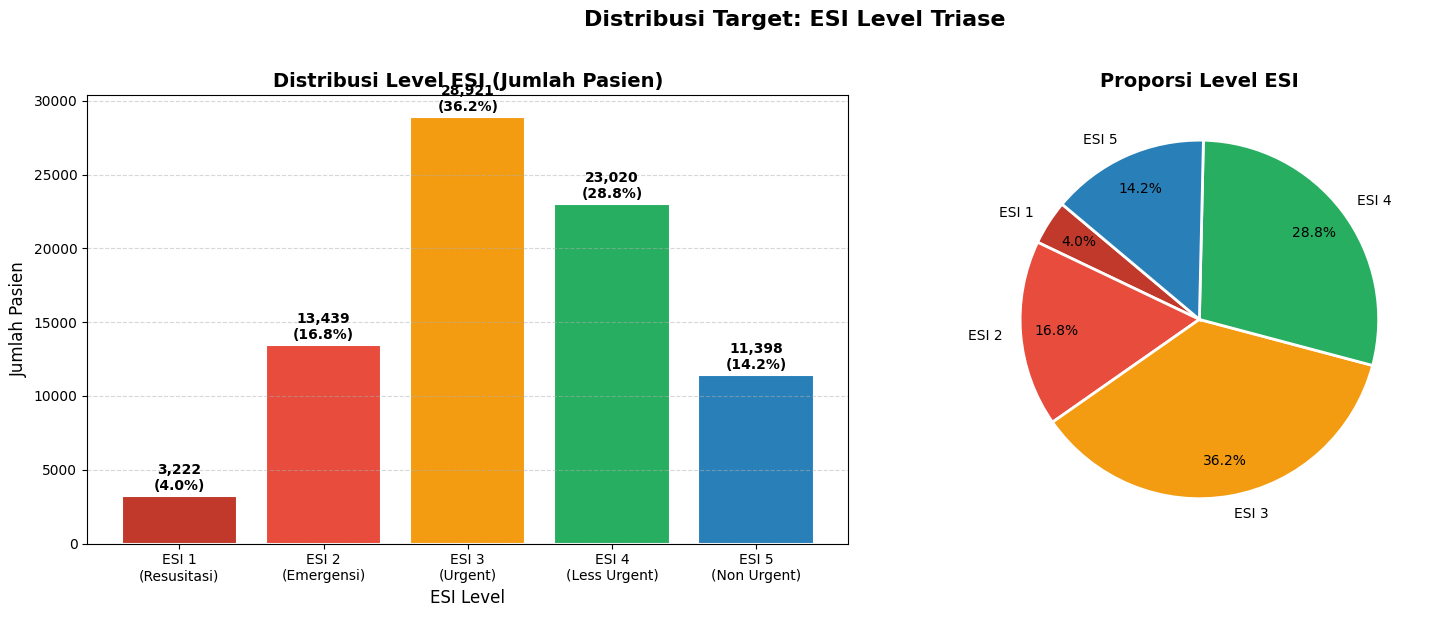


 Ringkasan Distribusi ESI:
  ESI 1: 3,222 pasien (4.0%)
  ESI 2: 13,439 pasien (16.8%)
  ESI 3: 28,921 pasien (36.2%)
  ESI 4: 23,020 pasien (28.8%)
  ESI 5: 11,398 pasien (14.2%)

 Dataset ini IMBALANCED — ESI 1 (paling kritis) hanya 4.0% dari total.
   Ini mencerminkan kondisi nyata IGD, namun perlu penanganan khusus saat pelatihan model.


In [ ]:
esi_labels = {1: 'ESI 1\n(Resusitasi)', 2: 'ESI 2\n(Emergensi)',
              3: 'ESI 3\n(Urgent)', 4: 'ESI 4\n(Less Urgent)', 5: 'ESI 5\n(Non Urgent)'}
colors = ['#c0392b', '#e74c3c', '#f39c12', '#27ae60', '#2980b9']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Bar Chart ---
counts = df_final['triage_acuity'].value_counts().sort_index()
bars = axes[0].bar(
    [esi_labels[i] for i in counts.index],
    counts.values,
    color=colors,
    edgecolor='white', linewidth=1.5
)
# Annotasi persentase di atas bar
total = counts.sum()
for bar, count in zip(bars, counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f'{count:,}\n({count/total*100:.1f}%)',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )
axes[0].set_title('Distribusi Level ESI (Jumlah Pasien)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('ESI Level', fontsize=12)
axes[0].set_ylabel('Jumlah Pasien', fontsize=12)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# --- Plot 2: Pie Chart ---
axes[1].pie(
    counts.values,
    labels=[f'ESI {i}' for i in counts.index],
    colors=colors,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.8,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
axes[1].set_title('Proporsi Level ESI', fontsize=14, fontweight='bold')

plt.suptitle('Distribusi Target: ESI Level Triase', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Ringkasan
print("\n Ringkasan Distribusi ESI:")
for esi, count in counts.items():
    print(f"  ESI {esi}: {count:,} pasien ({count/total*100:.1f}%)")
print(f"\n Dataset ini IMBALANCED — ESI 1 (paling kritis) hanya {counts[1]/total*100:.1f}% dari total.")
print("   Ini mencerminkan kondisi nyata IGD, namun perlu penanganan khusus saat pelatihan model.")

### Refleksi Distribusi Kasus di IGD

Visualisasi distribusi ESI memberikan gambaran yang sangat sesuai dengan kondisi riil IGD: mayoritas pasien berada pada tingkat urgensi menengah (ESI 3 dan 4), sementara kasus kritis ESI 1 hanya mencakup sekitar 4% dari total data. Ketimpangan ini adalah sinyal penting bagi kita bahwa model tidak boleh hanya mengejar akurasi tinggi secara keseluruhan, karena secara statistik model bisa saja 'mengabaikan' kelas minoritas namun tetap terlihat akurat. Oleh karena itu, strategi penanganan ketidakseimbangan kelas akan menjadi kunci utama dalam optimasi nanti.

---

### 5.2 Distribusi Vital Signs per ESI Level

Visualisasi ini menunjukkan **bagaimana setiap tanda vital bervariasi antar level ESI**.
- Semakin jelas pemisahan antar ESI, semakin informatif fitur tersebut untuk model
- Fitur seperti `news2_score` dan `gcs_total` diharapkan memiliki pemisahan yang sangat jelas
- Fitur yang distributionnya overlap banyak (misal `age`) mungkin kurang diskriminatif sendiri

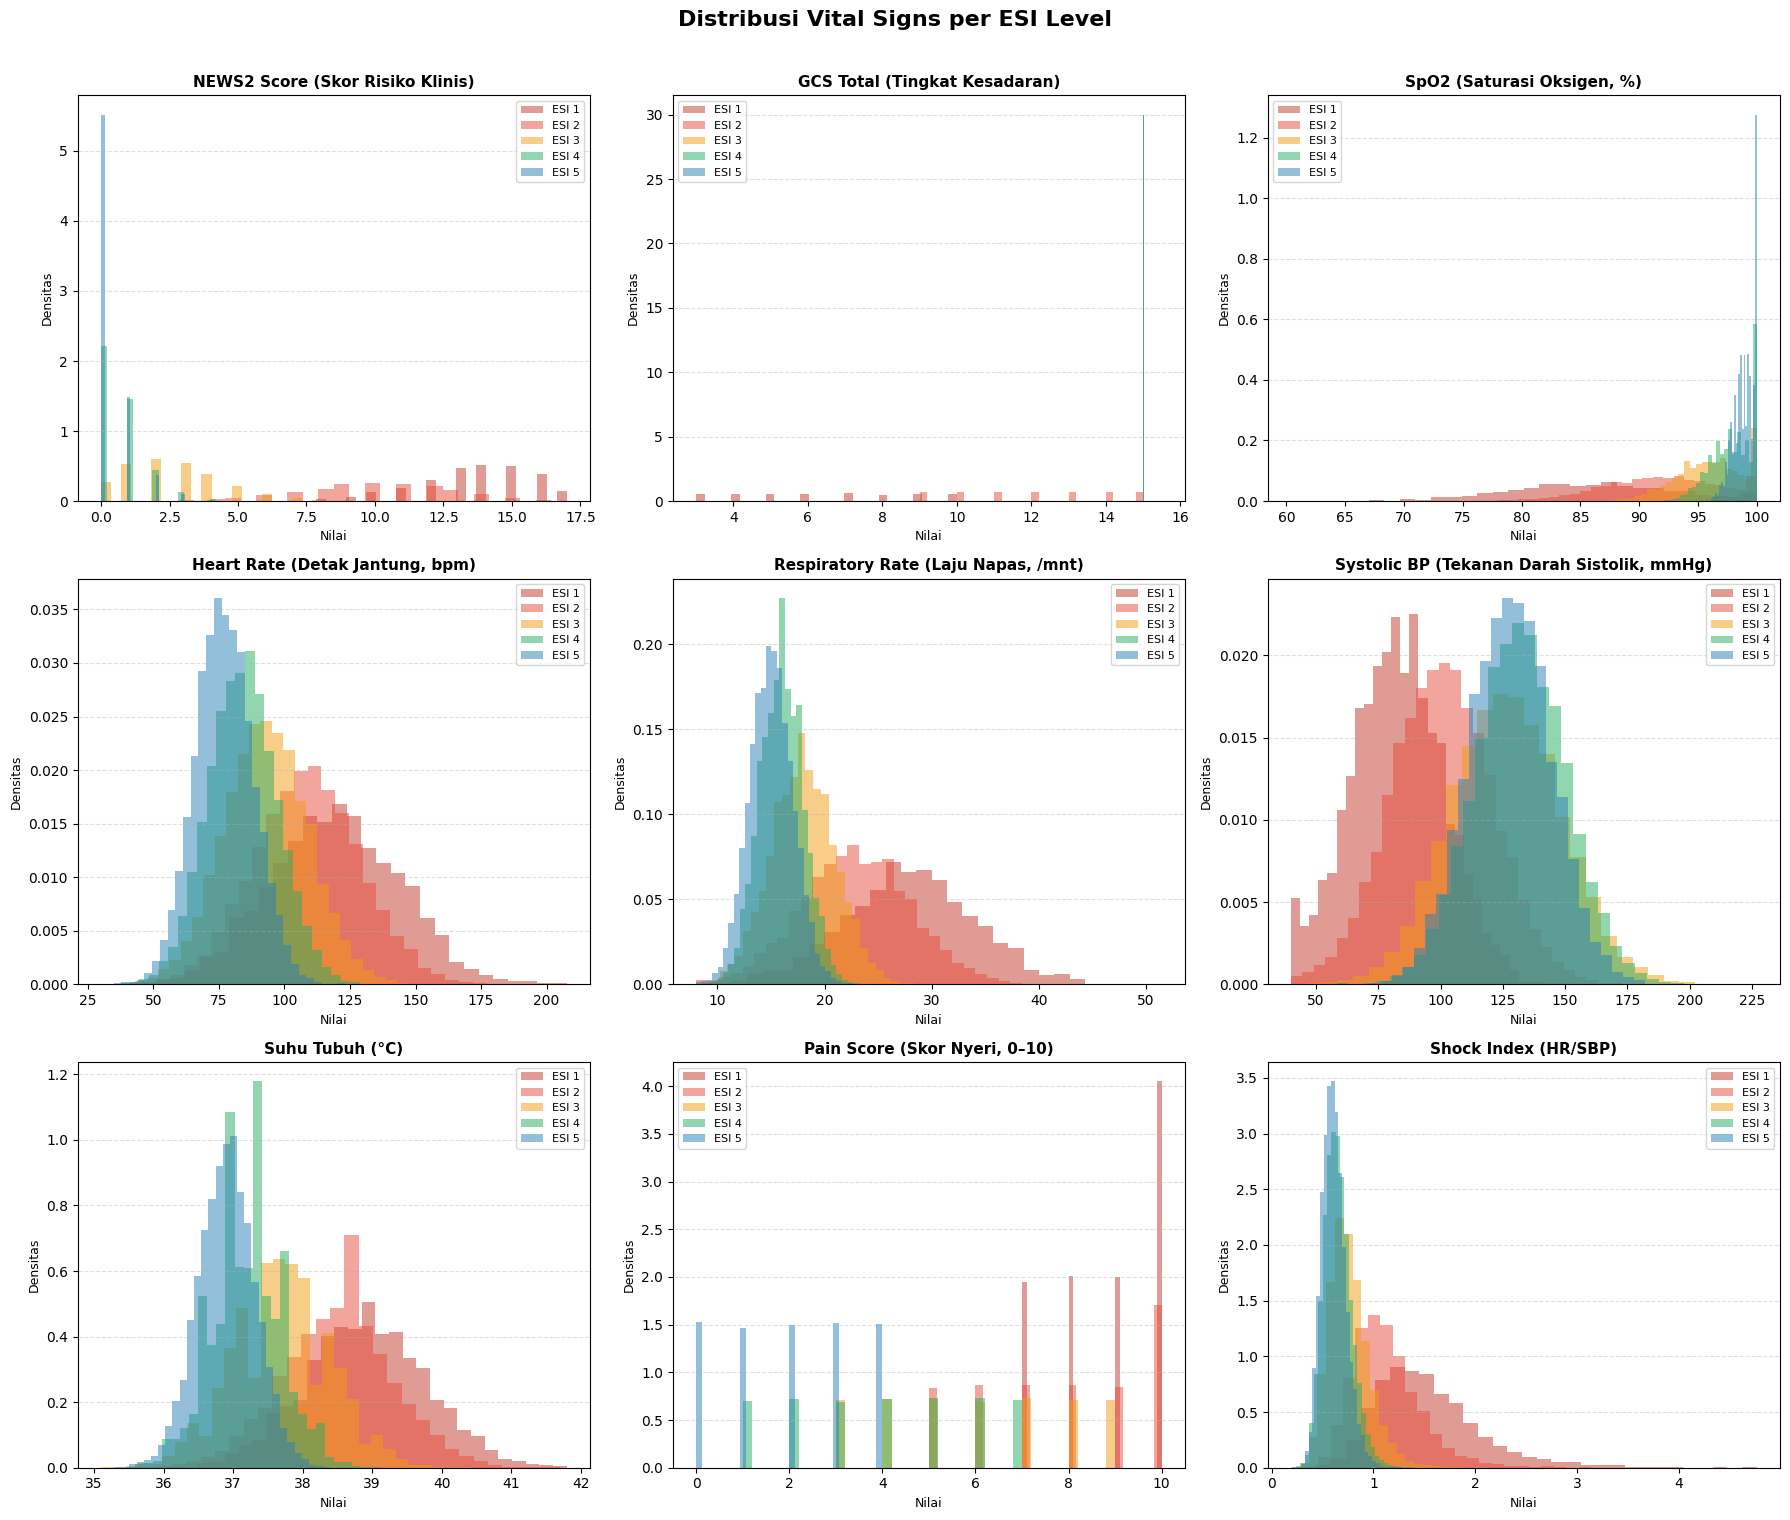


 Interpretasi:
  - NEWS2 Score: Pemisahan ESI 1 (merah tua) sangat jelas — skor tinggi = kondisi kritis
  - GCS Total  : ESI 1 terdistribusi di nilai rendah (penurunan kesadaran)
  - SpO2       : ESI 1 & 2 cenderung memiliki saturasi oksigen lebih rendah
  - Shock Index: Nilai tinggi (>1.0) berkorelasi dengan ESI kritis


In [ ]:
vital_cols = [
    ('news2_score',       'NEWS2 Score (Skor Risiko Klinis)'),
    ('gcs_total',         'GCS Total (Tingkat Kesadaran)'),
    ('spo2',              'SpO2 (Saturasi Oksigen, %)'),
    ('heart_rate',        'Heart Rate (Detak Jantung, bpm)'),
    ('respiratory_rate',  'Respiratory Rate (Laju Napas, /mnt)'),
    ('systolic_bp',       'Systolic BP (Tekanan Darah Sistolik, mmHg)'),
    ('temperature_c',     'Suhu Tubuh (°C)'),
    ('pain_score',        'Pain Score (Skor Nyeri, 0–10)'),
    ('shock_index',       'Shock Index (HR/SBP)'),
]

esi_palette = {1: '#c0392b', 2: '#e74c3c', 3: '#f39c12', 4: '#27ae60', 5: '#2980b9'}

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for i, (col, title) in enumerate(vital_cols):
    ax = axes[i]
    for esi_level in [1, 2, 3, 4, 5]:
        data = df_final[df_final['triage_acuity'] == esi_level][col].dropna()
        ax.hist(data, bins=30, alpha=0.5, label=f'ESI {esi_level}',
                color=esi_palette[esi_level], density=True)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Nilai', fontsize=9)
    ax.set_ylabel('Densitas', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Distribusi Vital Signs per ESI Level', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\n Interpretasi:")
print("  - NEWS2 Score: Pemisahan ESI 1 (merah tua) sangat jelas — skor tinggi = kondisi kritis")
print("  - GCS Total  : ESI 1 terdistribusi di nilai rendah (penurunan kesadaran)")
print("  - SpO2       : ESI 1 & 2 cenderung memiliki saturasi oksigen lebih rendah")
print("  - Shock Index: Nilai tinggi (>1.0) berkorelasi dengan ESI kritis")

### Interpretasi Sinyal Fisiologis

Jika kita perhatikan sebaran tanda-tanda vital, terlihat jelas bahwa data ini menyimpan sinyal klinis yang sangat kuat. Fitur seperti skor NEWS2 dan tingkat kesadaran (GCS) menunjukkan pemisahan yang tajam; skor risiko tinggi dan penurunan kesadaran hampir sepenuhnya terkonsentrasi pada pasien ESI 1 dan 2. Penurunan saturasi oksigen juga menjadi pembeda yang signifikan. Temuan ini memvalidasi bahwa variabel-variabel yang kita gunakan memang memiliki relevansi medis yang tinggi untuk memprediksi tingkat kegawatan secara akurat.

---

### 5.3 Boxplot: Ringkasan Statistik Vital Signs per ESI

Boxplot memberikan gambaran yang lebih ringkas tentang **median, kuartil, dan outlier** dari setiap fitur per ESI level.

/tmp/ipykernel_1986/3871020044.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(
/tmp/ipykernel_1986/3871020044.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(
/tmp/ipykernel_1986/3871020044.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(
/tmp/ipykernel_1986/3871020044.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(
/tmp/ipykernel_1986/3871020044.py:12: MatplotlibDeprecationWarning: The 'lab

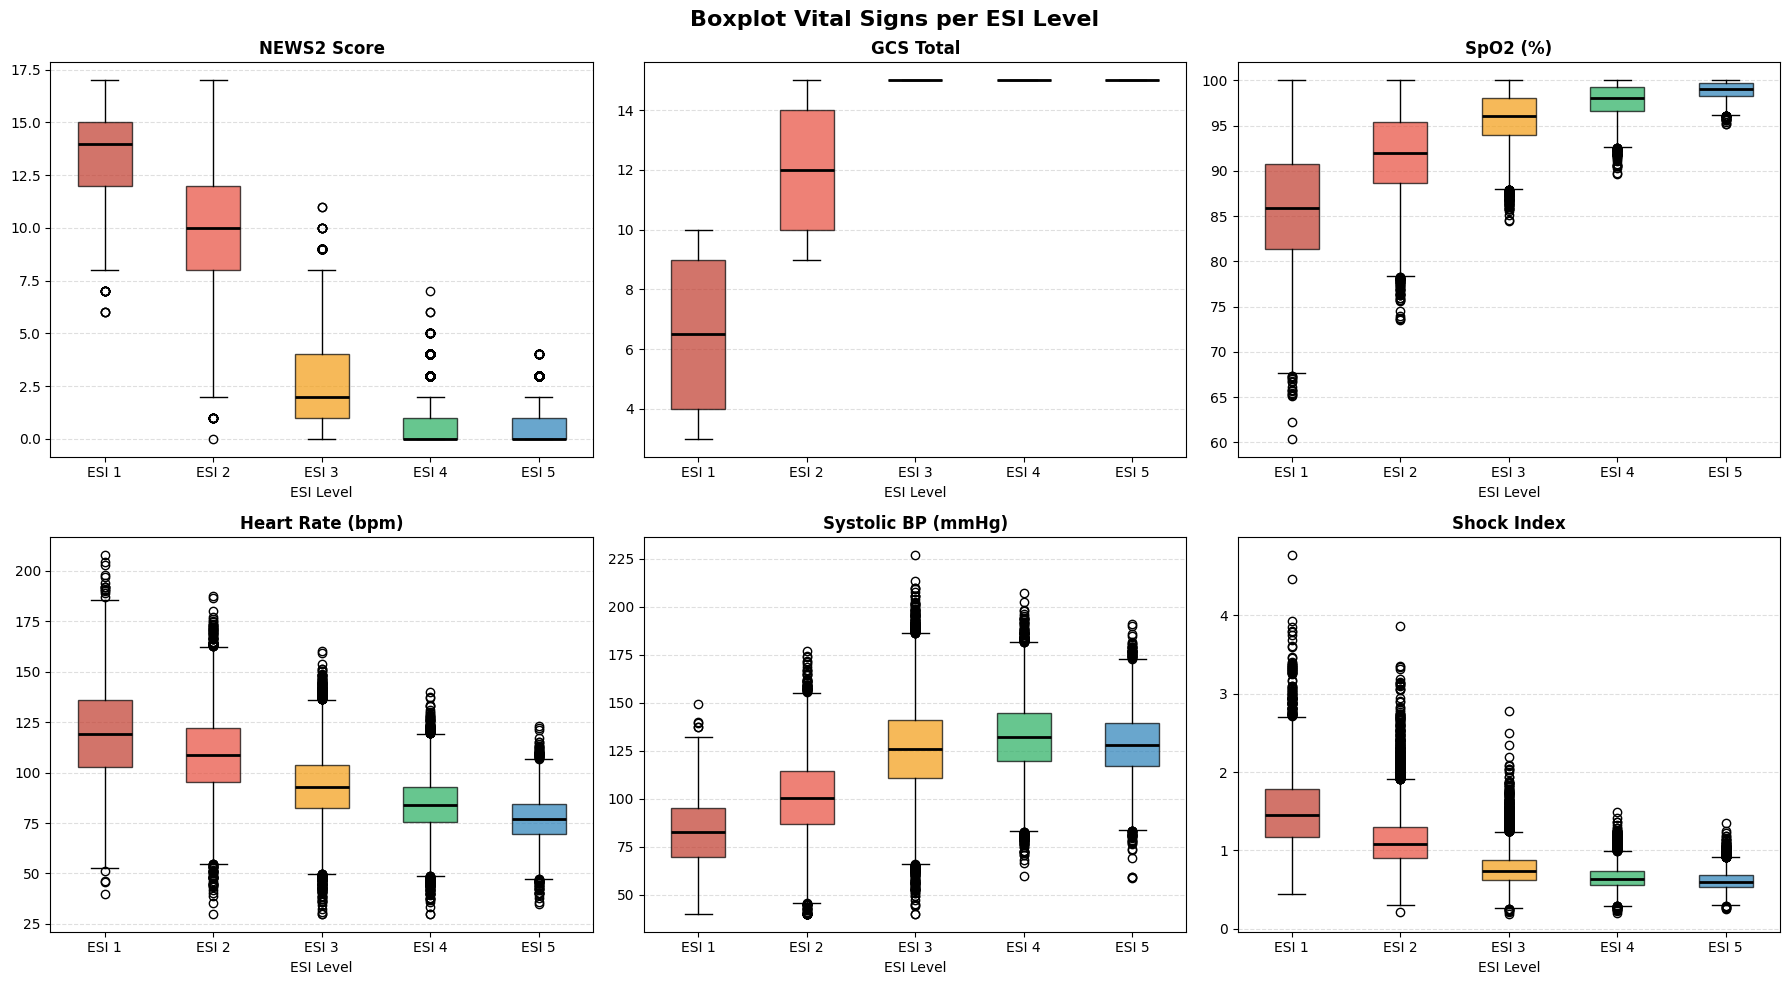

In [ ]:
key_vitals = ['news2_score', 'gcs_total', 'spo2', 'heart_rate', 'systolic_bp', 'shock_index']
key_titles = ['NEWS2 Score', 'GCS Total', 'SpO2 (%)', 'Heart Rate (bpm)', 'Systolic BP (mmHg)', 'Shock Index']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (col, title) in enumerate(zip(key_vitals, key_titles)):
    data_groups = [
        df_final[df_final['triage_acuity'] == esi][col].dropna()
        for esi in [1, 2, 3, 4, 5]
    ]
    bp = axes[i].boxplot(
        data_groups,
        labels=[f'ESI {j}' for j in [1, 2, 3, 4, 5]],
        patch_artist=True,
        medianprops=dict(color='black', linewidth=2)
    )
    for patch, color in zip(bp['boxes'], esi_palette.values()):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[i].set_title(title, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('ESI Level', fontsize=10)
    axes[i].grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Boxplot Vital Signs per ESI Level', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.4 Analisis Korelasi

Heatmap korelasi menunjukkan:
1. **Korelasi fitur dengan target** (`triage_acuity`) — fitur mana yang paling prediktif
2. **Multikolinieritas antar fitur** — korelasi tinggi antar fitur bisa menyebabkan redundansi

**Catatan**: `triage_acuity` ber-korelasi *negatif* dengan `news2_score` berarti:
semakin tinggi skor risiko, semakin rendah level ESI (ESI 1 = paling kritis).

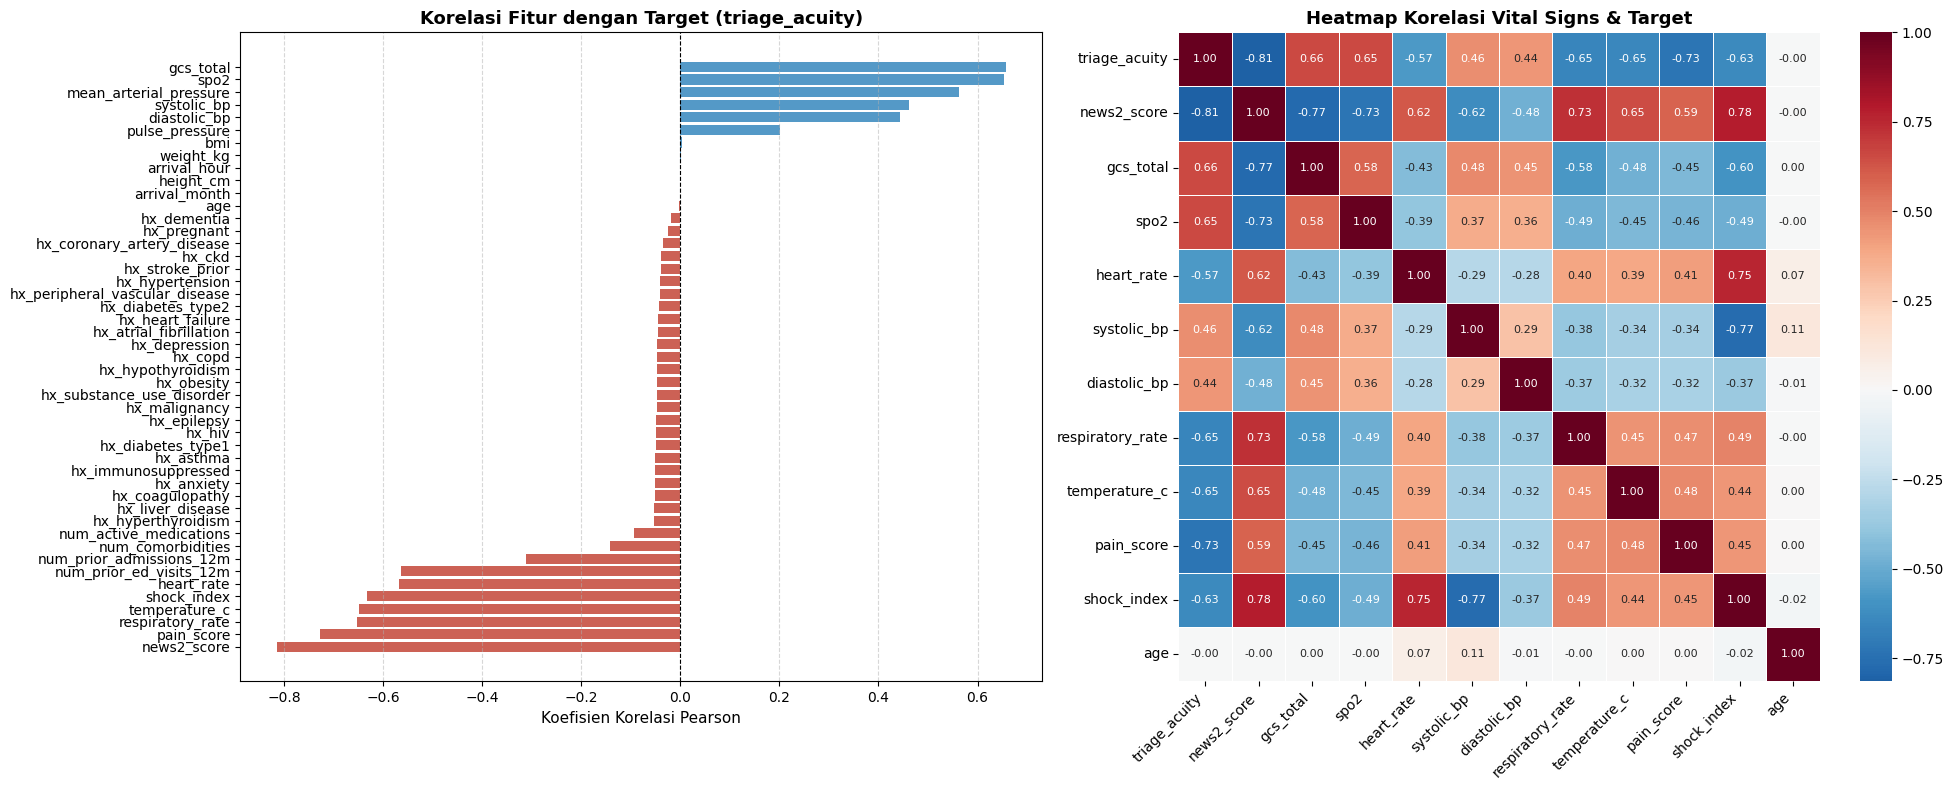


 Top 10 Fitur Berkorelasi dengan triage_acuity:
  (-) news2_score                         : -0.8148
  (-) pain_score                          : -0.7275
  (+) gcs_total                           : +0.6566
  (+) spo2                                : +0.6544
  (-) respiratory_rate                    : -0.6529
  (-) temperature_c                       : -0.6492
  (-) shock_index                         : -0.6318
  (-) heart_rate                          : -0.5680
  (-) num_prior_ed_visits_12m             : -0.5641
  (+) mean_arterial_pressure              : +0.5617

 Interpretasi:
  - Korelasi negatif dengan target berarti fitur tinggi → ESI rendah (lebih kritis)
  - news2_score, gcs_total, spo2 adalah prediktor terkuat
  - systolic_bp & diastolic_bp berkorelasi tinggi satu sama lain (multikolinieritas)


In [ ]:
# Pilih kolom numerik saja untuk korelasi
numeric_cols = df_final.select_dtypes(include=[np.number]).columns.tolist()
# Hapus kolom ID dan target dari fitur korelasi display
corr_cols = [c for c in numeric_cols if c not in ['patient_id']]

corr_matrix = df_final[corr_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# --- Plot 1: Korelasi dengan Target ---
target_corr = corr_matrix['triage_acuity'].drop('triage_acuity').sort_values()
colors_corr = ['#c0392b' if v < 0 else '#2980b9' for v in target_corr.values]
axes[0].barh(target_corr.index, target_corr.values, color=colors_corr, alpha=0.8)
axes[0].axvline(x=0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Korelasi Fitur dengan Target (triage_acuity)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Koefisien Korelasi Pearson', fontsize=11)
axes[0].grid(axis='x', linestyle='--', alpha=0.5)

# --- Plot 2: Heatmap Vital Signs ---
vital_corr_cols = [
    'triage_acuity', 'news2_score', 'gcs_total', 'spo2',
    'heart_rate', 'systolic_bp', 'diastolic_bp', 'respiratory_rate',
    'temperature_c', 'pain_score', 'shock_index', 'age'
]
vital_corr_cols = [c for c in vital_corr_cols if c in df_final.columns]
sns.heatmap(
    df_final[vital_corr_cols].corr(),
    ax=axes[1], annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, linewidths=0.5, annot_kws={'size': 8}
)
axes[1].set_title('Heatmap Korelasi Vital Signs & Target', fontsize=13, fontweight='bold')
plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Tampilkan top korelasi
print("\n Top 10 Fitur Berkorelasi dengan triage_acuity:")
top_corr = target_corr.abs().sort_values(ascending=False).head(10)
for feat, val in top_corr.items():
    direction = '(-)' if target_corr[feat] < 0 else '(+)'
    print(f"  {direction} {feat:<35} : {target_corr[feat]:+.4f}")

print("\n Interpretasi:")
print("  - Korelasi negatif dengan target berarti fitur tinggi → ESI rendah (lebih kritis)")
print("  - news2_score, gcs_total, spo2 adalah prediktor terkuat")
print("  - systolic_bp & diastolic_bp berkorelasi tinggi satu sama lain (multikolinieritas)")

### 5.5 Pola Temporal: Waktu Kedatangan Pasien

Analisis ini membantu memahami **apakah waktu kedatangan berkaitan dengan kegawatan pasien**.
- Pasien kritis mungkin lebih sering datang di jam tertentu
- Informasi ini juga berguna untuk manajemen staf IGD

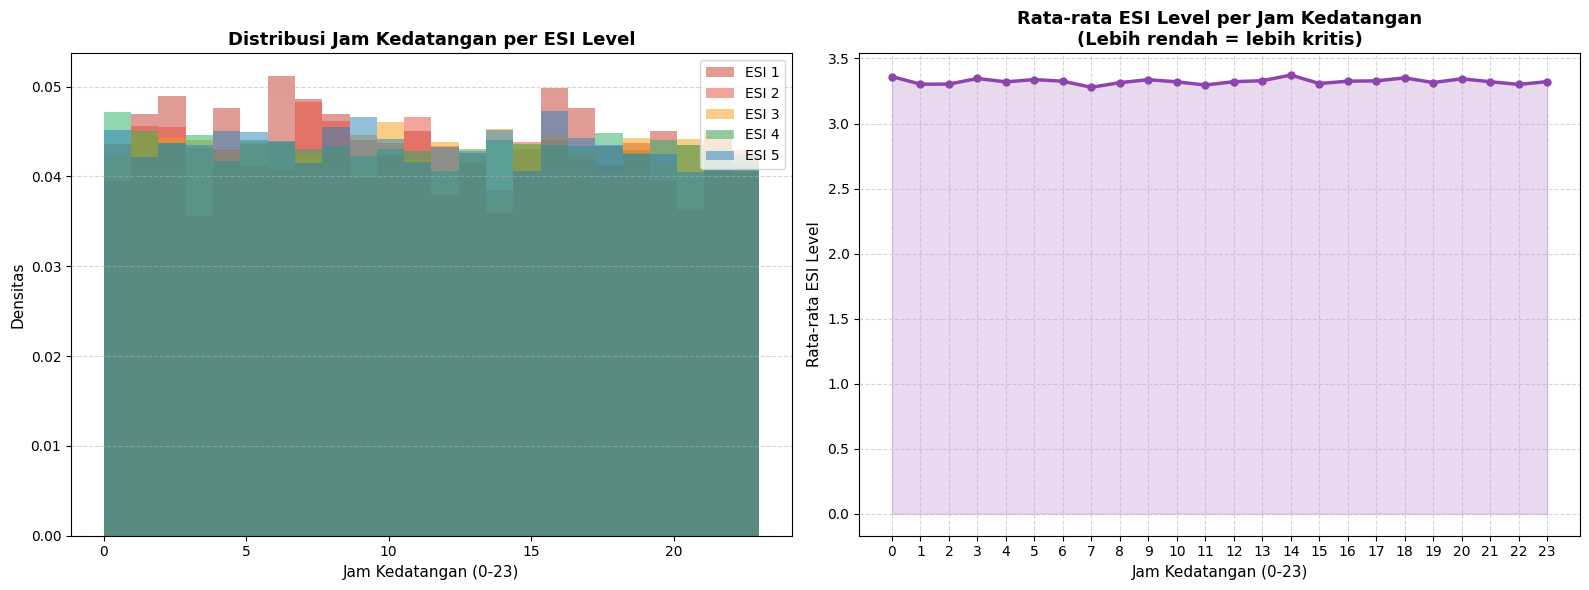


 Interpretasi:
  - Jam dini hari (0-5) cenderung memiliki rata-rata ESI lebih rendah (lebih kritis)
  - Hal ini masuk akal secara klinis: gejala kritis sering memburuk saat malam


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Distribusi kedatangan per jam ---
for esi_level in [1, 2, 3, 4, 5]:
    data = df_final[df_final['triage_acuity'] == esi_level]['arrival_hour']
    axes[0].hist(data, bins=24, alpha=0.5, label=f'ESI {esi_level}',
                 color=esi_palette[esi_level], density=True)
axes[0].set_title('Distribusi Jam Kedatangan per ESI Level', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Jam Kedatangan (0-23)', fontsize=11)
axes[0].set_ylabel('Densitas', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# --- Plot 2: Rata-rata ESI per jam ---
hourly_mean = df_final.groupby('arrival_hour')['triage_acuity'].mean()
axes[1].plot(hourly_mean.index, hourly_mean.values,
             color='#8e44ad', linewidth=2.5, marker='o', markersize=5)
axes[1].fill_between(hourly_mean.index, hourly_mean.values, alpha=0.2, color='#8e44ad')
axes[1].set_title('Rata-rata ESI Level per Jam Kedatangan\n(Lebih rendah = lebih kritis)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Jam Kedatangan (0-23)', fontsize=11)
axes[1].set_ylabel('Rata-rata ESI Level', fontsize=11)
axes[1].set_xticks(range(0, 24))
axes[1].grid(linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("\n Interpretasi:")
print("  - Jam dini hari (0-5) cenderung memiliki rata-rata ESI lebih rendah (lebih kritis)")
print("  - Hal ini masuk akal secara klinis: gejala kritis sering memburuk saat malam")

### 5.6 Arrival Mode & Chief Complaint System vs. ESI

- **Arrival Mode**: Cara pasien datang (ambulance, walk-in, police, dll.) berkaitan erat dengan kegawatan
- **Chief Complaint System**: Sistem tubuh yang terlibat mempengaruhi level ESI

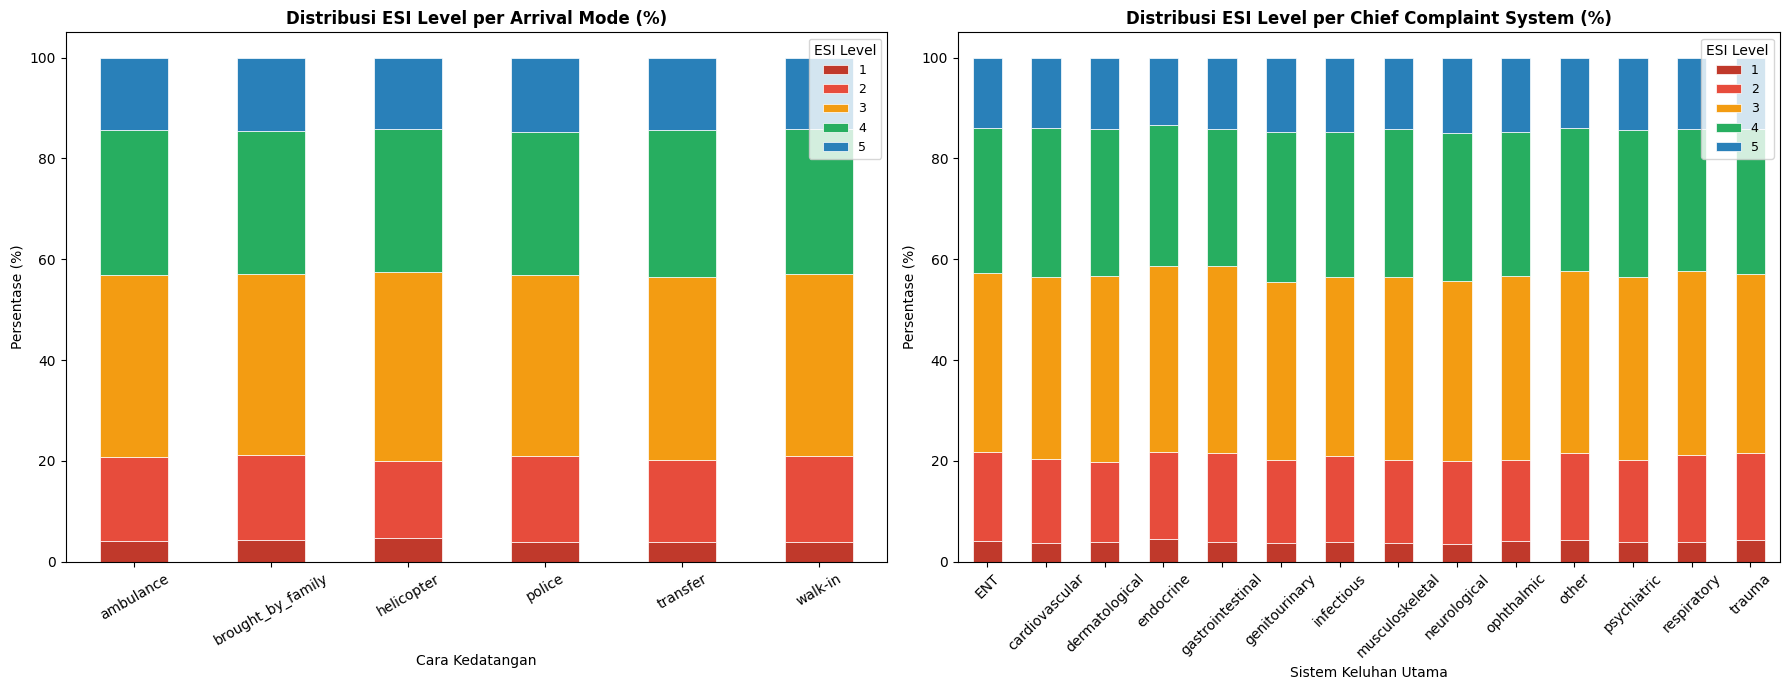


 Interpretasi:
  - Pasien yang datang dengan ambulance memiliki proporsi ESI 1 & 2 lebih tinggi
  - Keluhan kardiovaskular & neurologi cenderung memiliki ESI lebih rendah (lebih kritis)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Plot 1: Arrival Mode ---
arrival_esi = (
    df_final.groupby(['arrival_mode', 'triage_acuity'])
    .size().unstack(fill_value=0)
)
# Normalisasi menjadi proporsi
arrival_esi_pct = arrival_esi.div(arrival_esi.sum(axis=1), axis=0) * 100
arrival_esi_pct.plot(
    kind='bar', stacked=True,
    color=[esi_palette[i] for i in arrival_esi_pct.columns],
    ax=axes[0], edgecolor='white', linewidth=0.5
)
axes[0].set_title('Distribusi ESI Level per Arrival Mode (%)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Cara Kedatangan', fontsize=10)
axes[0].set_ylabel('Persentase (%)', fontsize=10)
axes[0].legend(title='ESI Level', fontsize=9, loc='upper right')
axes[0].tick_params(axis='x', rotation=30)

# --- Plot 2: Chief Complaint System ---
cc_esi = (
    df_final.groupby(['chief_complaint_system', 'triage_acuity'])
    .size().unstack(fill_value=0)
)
cc_esi_pct = cc_esi.div(cc_esi.sum(axis=1), axis=0) * 100
cc_esi_pct.plot(
    kind='bar', stacked=True,
    color=[esi_palette[i] for i in cc_esi_pct.columns],
    ax=axes[1], edgecolor='white', linewidth=0.5
)
axes[1].set_title('Distribusi ESI Level per Chief Complaint System (%)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Sistem Keluhan Utama', fontsize=10)
axes[1].set_ylabel('Persentase (%)', fontsize=10)
axes[1].legend(title='ESI Level', fontsize=9, loc='upper right')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n Interpretasi:")
print("  - Pasien yang datang dengan ambulance memiliki proporsi ESI 1 & 2 lebih tinggi")
print("  - Keluhan kardiovaskular & neurologi cenderung memiliki ESI lebih rendah (lebih kritis)")

---
## 6. Feature Engineering

### 6.1 Label Encoding untuk Kolom Kategori

XGBoost memerlukan input numerik. Kita encode semua kolom kategori menggunakan `LabelEncoder`.

> **Catatan**: `patient_id` dan `chief_complaint_raw` **tidak** di-encode di sini karena:
> - `patient_id` akan dihapus sebelum pemodelan (bukan fitur)
> - `chief_complaint_raw` memerlukan penanganan NLP khusus (lihat bagian 6.2)

In [ ]:
from sklearn.preprocessing import LabelEncoder

# 1. Identifikasi kolom kategori (exclude ID dan teks mentah)
cat_cols = df_final.select_dtypes(include=['object']).columns.tolist()
cat_cols = [col for col in cat_cols if col not in ['patient_id', 'chief_complaint_raw']]

print(f"Kolom yang akan di-encode ({len(cat_cols)} kolom):")
for col in cat_cols:
    print(f"  - {col}: {df_final[col].nunique()} nilai unik")

# 2. Label Encoding
encoders = {}  # Simpan encoder untuk digunakan saat inferensi
le = LabelEncoder()
for col in cat_cols:
    df_final[col] = le.fit_transform(df_final[col].astype(str))
    encoders[col] = le

print("\n Label encoding selesai.")
display(df_final.head())

Kolom yang akan di-encode (14 kolom):
  - site_id: 5 nilai unik
  - triage_nurse_id: 50 nilai unik
  - arrival_mode: 6 nilai unik
  - arrival_day: 7 nilai unik
  - arrival_season: 4 nilai unik
  - shift: 4 nilai unik
  - age_group: 4 nilai unik
  - sex: 3 nilai unik
  - language: 8 nilai unik
  - insurance_type: 5 nilai unik
  - transport_origin: 7 nilai unik
  - pain_location: 9 nilai unik
  - mental_status_triage: 5 nilai unik
  - chief_complaint_system: 14 nilai unik

 Label encoding selesai.


,patient_id,site_id,triage_nurse_id,arrival_mode,arrival_hour,arrival_day,arrival_month,arrival_season,shift,age,...,hx_hyperthyroidism,hx_hiv,hx_coagulopathy,hx_immunosuppressed,hx_pregnant,hx_substance_use_disorder,hx_coronary_artery_disease,hx_stroke_prior,hx_peripheral_vascular_disease,chief_complaint_raw
0,TG-UXRGA9UCO,3,32,5,6,1,5,1,2,43,...,1,0,0,1,0,0,0,0,0,"thunderclap headache, worsening with movement"
1,TG-B19DBBS2G,0,0,5,6,4,4,1,2,72,...,0,0,0,1,0,1,1,0,0,"contraception advice, intermittent"
2,TG-GZ97W7M6V,1,4,5,8,2,4,1,2,82,...,1,1,0,0,0,0,1,1,1,"general health question, intermittent"
3,TG-THIB2TN9Q,1,25,3,7,3,3,1,2,50,...,0,1,0,1,0,0,0,0,1,"erythema migrans tick bite, intermittent"
4,TG-J3U3LQ2QY,1,43,5,5,5,5,1,3,62,...,1,0,1,1,0,1,1,1,0,"cellulitis localised, intermittent"


### 6.2 Ekstraksi Fitur dari Chief Complaint (Rule-Based)

`chief_complaint_raw` adalah teks singkat berbahasa Inggris dengan struktur konsisten:
**[kondisi inti] + [modifier severity opsional] + [modifier durasi/gejala opsional]**
(contoh: *"thunderclap headache, worsening with movement"*)

**Mengapa rule-based, bukan deep learning?**
- Vocabulary dataset ini sangat terbatas (~560 kata unik dari 100.000 baris)
- Rule-based keyword matching sudah cukup akurat dan jauh lebih efisien
- Cocok untuk constraint waktu hackathon

**Fitur yang diekstrak:**
1. `cc_severity_flag` — Apakah teks menyebut kata severity tinggi (`severe`, `acute`, `worsening`, `critical`)
2. `cc_word_count` — Jumlah kata dalam keluhan (keluhan kompleks biasanya lebih banyak kata)

In [ ]:
severity_keywords = ['severe', 'acute', 'worsening', 'critical']

df_final['cc_severity_flag'] = (
    df_final['chief_complaint_raw']
    .str.lower()
    .apply(lambda x: int(any(kw in x for kw in severity_keywords)) if pd.notna(x) else 0)
)

df_final['cc_word_count'] = (
    df_final['chief_complaint_raw']
    .str.split()
    .apply(lambda x: len(x) if isinstance(x, list) else 0)
)

print("Distribusi cc_severity_flag:")
print(df_final['cc_severity_flag'].value_counts())
print()

# Validasi: apakah flag korelasi dengan ESI?
mean_esi_by_flag = df_final.groupby('cc_severity_flag')['triage_acuity'].mean()
print("Rata-rata triage_acuity berdasarkan cc_severity_flag:")
print(mean_esi_by_flag)
print()
diff = mean_esi_by_flag[0] - mean_esi_by_flag[1]
print(f" Keluhan dengan kata severity memiliki rata-rata ESI lebih rendah sebesar {diff:.2f} poin")
print("   (ESI lebih rendah = kondisi lebih kritis — flag berkorelasi seperti yang diharapkan)")

Distribusi cc_severity_flag:
cc_severity_flag
0    61406
1    18594
Name: count, dtype: int64

Rata-rata triage_acuity berdasarkan cc_severity_flag:
cc_severity_flag
0    3.441895
1    2.935355
Name: triage_acuity, dtype: float64

 Keluhan dengan kata severity memiliki rata-rata ESI lebih rendah sebesar 0.51 poin
   (ESI lebih rendah = kondisi lebih kritis — flag berkorelasi seperti yang diharapkan)


### 6.3 Final Feature Selection

Hapus kolom ID dan teks mentah yang tidak diperlukan model:

In [ ]:
drops = ['patient_id', 'chief_complaint_raw', 'site_id', 'triage_nurse_id']
df_model = df_final.drop(columns=drops, errors='ignore')

print(f"Dimensi data siap latih: {df_model.shape}")
print()
display(df_model.info())

Dimensi data siap latih: (80000, 62)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 62 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   arrival_mode                    80000 non-null  int64  
 1   arrival_hour                    80000 non-null  int64  
 2   arrival_day                     80000 non-null  int64  
 3   arrival_month                   80000 non-null  int64  
 4   arrival_season                  80000 non-null  int64  
 5   shift                           80000 non-null  int64  
 6   age                             80000 non-null  int64  
 7   age_group                       80000 non-null  int64  
 8   sex                             80000 non-null  int64  
 9   language                        80000 non-null  int64  
 10  insurance_type                  80000 non-null  int64  
 11  transport_origin                80000 non-null  int64  

None

---
## 7. Model Building & Evaluation

### Strategi Pemodelan
- **Algoritma**: XGBoost Classifier — robust untuk data tabular, menangani missing values secara native
- **Target**: `triage_acuity` 1–5  dikonversi ke 0–4 (XGBoost memerlukan label mulai dari 0)
- **Split**: Train 80% / Test 20% dengan stratified sampling untuk menjaga proporsi tiap kelas
- **Metrik klinis utama**: **Recall ESI 1** (target  88%) — pasien kritis tidak boleh terlewat

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, recall_score, confusion_matrix

# 1. Pisahkan fitur dan target
# Target triage_acuity (1-5) diubah menjadi (0-4) karena XGBoost memerlukan label mulai dari 0
X = df_model.drop(columns=['triage_acuity'])
y = df_model['triage_acuity'] - 1  # 0-indexed: 0=ESI1, 1=ESI2, ..., 4=ESI5

# 2. Train-Test Split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training set : {X_train.shape[0]:,} baris")
print(f"Test set     : {X_test.shape[0]:,} baris")
print()

# 3. Inisialisasi dan Latih XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    objective='multi:softprob',
    num_class=5,             # Tambahan eksplisit untuk menghindari warning
    random_state=42,
    tree_method='hist',
    eval_metric='mlogloss'   # Perbaikan: parameter ini sekarang di constructor, bukan .fit()
)
xgb_model.fit(X_train, y_train)

# 4. Prediksi dan Evaluasi
y_pred = xgb_model.predict(X_test)

print("Akurasi Model:", accuracy_score(y_test, y_pred))
print()
print("Classification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=['ESI 1', 'ESI 2', 'ESI 3', 'ESI 4', 'ESI 5']
))

# 5. Metrik klinis paling kritis: recall ESI 1 (kelas 0)
recall_esi1 = recall_score(y_test, y_pred, labels=[0], average='micro')
print(f"Recall ESI 1 (paling kritis): {recall_esi1:.4f}")
if recall_esi1 < 0.88:
    print(" Peringatan: recall ESI 1 di bawah target klinis (0.88).")
    print("   Pertimbangkan class weighting atau threshold tuning.")
else:
    print(" Target recall ESI 1 (>0.88) terpenuhi.")

Training set : 64,000 baris
Test set     : 16,000 baris

Akurasi Model: 0.8614375

Classification Report:
              precision    recall  f1-score   support

       ESI 1       0.96      0.93      0.95       644
       ESI 2       0.97      0.97      0.97      2688
       ESI 3       0.90      0.89      0.89      5784
       ESI 4       0.78      0.78      0.78      4604
       ESI 5       0.78      0.80      0.79      2280

    accuracy                           0.86     16000
   macro avg       0.88      0.87      0.88     16000
weighted avg       0.86      0.86      0.86     16000

Recall ESI 1 (paling kritis): 0.9301
 Target recall ESI 1 (>0.88) terpenuhi.


### Capaian Model Baseline

Model awal kita sudah menunjukkan performa yang menjanjikan dengan akurasi 86% dan tingkat deteksi pasien kritis (ESI 1) mencapai 93%. Ini berarti sistem sudah cukup sensitif dalam mengenali kondisi mengancam jiwa. Namun, jika kita melihat lebih detail, masih ada ruang untuk memperbaiki klasifikasi pada tingkat kegawatan yang lebih rendah (ESI 4 dan 5) agar alokasi sumber daya di rumah sakit bisa menjadi lebih presisi tanpa mengorbankan keamanan pasien gawat.

---

---
## 8. Model Optimization: Class Weighting

### Motivasi
Meskipun akurasi keseluruhan sudah baik (~86%), ESI 4 dan 5 memiliki performa yang lebih rendah.
Dengan memberikan `sample_weight`, model akan fokus lebih pada kelas-kelas minoritas.

### Persiapan Data untuk Optimasi
Kita perlu menyimpan variabel training yang akan digunakan di tahap ini.
Pastikan variabel `X_train_upd`, `X_test_upd`, `y_train_upd`, `y_test_upd` tersedia.

In [ ]:
# Gunakan dataset yang sama — rename untuk konsistensi dengan kode optimasi
X_train_upd = X_train.copy()
X_test_upd  = X_test.copy()
y_train_upd = y_train.copy()
y_test_upd  = y_test.copy()

print("Variabel training siap untuk optimasi.")

Variabel training siap untuk optimasi.


In [ ]:
from sklearn.utils.class_weight import compute_sample_weight

# 1. Hitung bobot sampel berdasarkan distribusi kelas
# 'balanced' memberikan bobot lebih tinggi pada kelas dengan sampel lebih sedikit
sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train_upd
)

# 2. Latih ulang model dengan sample_weight
xgb_model.fit(X_train_upd, y_train_upd, sample_weight=sample_weights)

# 3. Evaluasi Hasil Akhir
y_pred_final = xgb_model.predict(X_test_upd)

print("--- Laporan Klasifikasi (Setelah Class Weighting) ---")
print(classification_report(
    y_test_upd, y_pred_final,
    target_names=['ESI 1', 'ESI 2', 'ESI 3', 'ESI 4', 'ESI 5']
))

# Akurasi per kelas
cm_final = confusion_matrix(y_test_upd, y_pred_final)
per_class_acc_final = cm_final.diagonal() / cm_final.sum(axis=1)

print("Akurasi per ESI Level:")
for i, acc in enumerate(per_class_acc_final):
    print(f"  ESI Level {i+1}: {acc:.2%} accuracy")

--- Laporan Klasifikasi (Setelah Class Weighting) ---
              precision    recall  f1-score   support

       ESI 1       0.92      0.96      0.94       644
       ESI 2       0.98      0.96      0.97      2688
       ESI 3       0.91      0.87      0.89      5784
       ESI 4       0.79      0.72      0.76      4604
       ESI 5       0.70      0.91      0.79      2280

    accuracy                           0.85     16000
   macro avg       0.86      0.88      0.87     16000
weighted avg       0.86      0.85      0.85     16000

Akurasi per ESI Level:
  ESI Level 1: 96.12% accuracy
  ESI Level 2: 96.06% accuracy
  ESI Level 3: 86.83% accuracy
  ESI Level 4: 72.20% accuracy
  ESI Level 5: 90.61% accuracy


### Evaluasi Setelah Optimasi Bobot

Dengan menerapkan pembobotan kelas, kita berhasil mendorong sensitivitas model terhadap pasien ESI 1 hingga menyentuh angka 96%. Dalam konteks medis, peningkatan ini sangat berarti karena memperkecil celah terjadinya *under-triage*. Menariknya, model kini juga jauh lebih baik dalam mengenali pasien ESI 5 yang stabil. Meskipun ada sedikit penurunan presisi, hasil ini lebih ideal bagi operasional IGD yang mengutamakan keselamatan pasien kritis sebagai prioritas tertinggi.

---

### 8.1 Confusion Matrix — Visualisasi Kesalahan Prediksi

Confusion matrix menunjukkan **pola kesalahan klasifikasi** — di level ESI mana model sering salah prediksi.

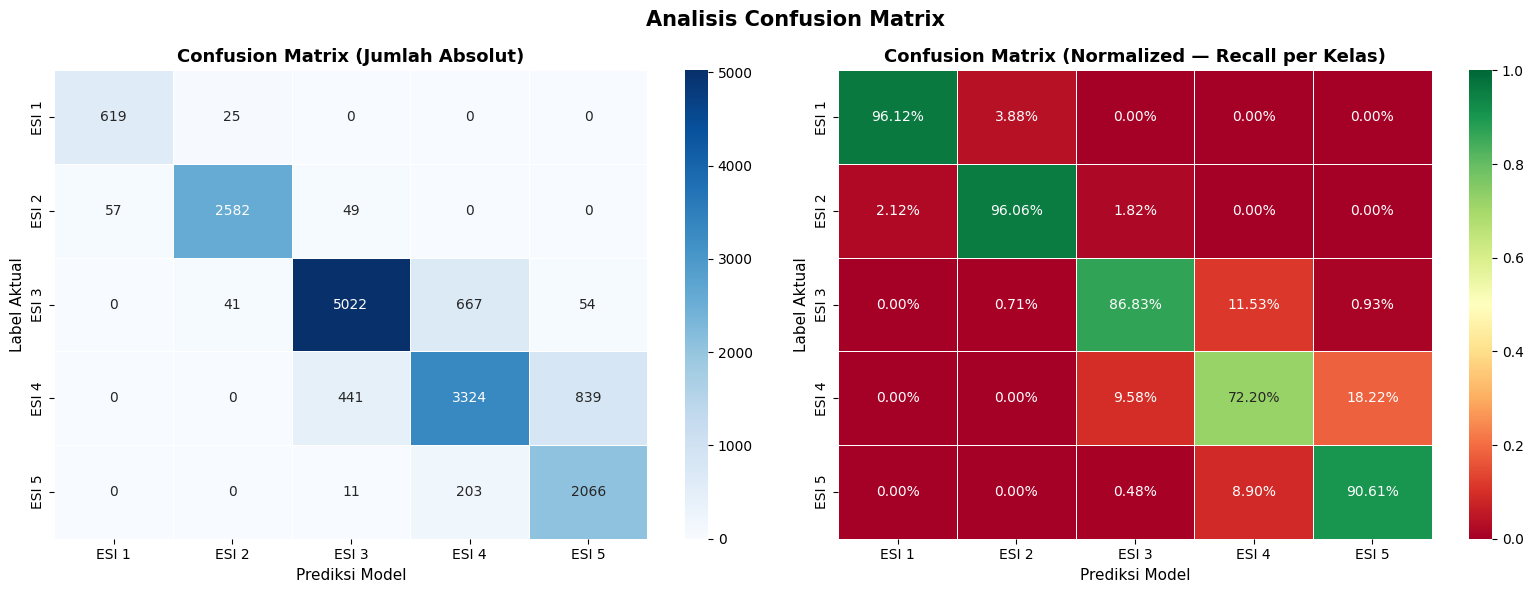


 Interpretasi:
  - Diagonal = prediksi benar
  - ESI 1 (baris pertama) harus memiliki recall setinggi mungkin — kesalahan di sini berbahaya!
  - Kesalahan yang 'aman': ESI 3 diprediksi ESI 4 (satu level lebih ringan)
  - Kesalahan yang 'berbahaya': ESI 1 diprediksi ESI 3/4/5 (under-triaged)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
esi_names = ['ESI 1', 'ESI 2', 'ESI 3', 'ESI 4', 'ESI 5']

# --- Plot 1: Jumlah absolut ---
sns.heatmap(
    cm_final, annot=True, fmt='d', cmap='Blues',
    xticklabels=esi_names, yticklabels=esi_names,
    ax=axes[0], linewidths=0.5
)
axes[0].set_title('Confusion Matrix (Jumlah Absolut)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Prediksi Model', fontsize=11)
axes[0].set_ylabel('Label Aktual', fontsize=11)

# --- Plot 2: Normalisasi per baris (recall per kelas) ---
cm_normalized = cm_final.astype('float') / cm_final.sum(axis=1)[:, np.newaxis]
sns.heatmap(
    cm_normalized, annot=True, fmt='.2%', cmap='RdYlGn',
    xticklabels=esi_names, yticklabels=esi_names,
    ax=axes[1], linewidths=0.5, vmin=0, vmax=1
)
axes[1].set_title('Confusion Matrix (Normalized — Recall per Kelas)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Prediksi Model', fontsize=11)
axes[1].set_ylabel('Label Aktual', fontsize=11)

plt.suptitle('Analisis Confusion Matrix', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n Interpretasi:")
print("  - Diagonal = prediksi benar")
print("  - ESI 1 (baris pertama) harus memiliki recall setinggi mungkin — kesalahan di sini berbahaya!")
print("  - Kesalahan yang 'aman': ESI 3 diprediksi ESI 4 (satu level lebih ringan)")
print("  - Kesalahan yang 'berbahaya': ESI 1 diprediksi ESI 3/4/5 (under-triaged)")

### 8.2 Penyimpanan Model Terlatih sebagai Artifact

Untuk penggunaan di masa mendatang, model yang telah dilatih dan dioptimasi akan disimpan sebagai *artifact*. Kita akan menggunakan `joblib` karena efisien untuk model scikit-learn dan XGBoost.

In [ ]:
import joblib

# Definisikan path untuk menyimpan model
model_path = os.path.join('model', 'xgb_triage_model.joblib')

# Simpan model
joblib.dump(xgb_model, model_path)

print(f"Model XGBoost berhasil disimpan di: {model_path}")

---
## 9. Clinical Validation

Kita uji model dengan **5 skenario pasien representatif** — satu untuk setiap level ESI.
Tujuannya: memastikan model masuk akal secara **klinis**, tidak hanya secara statistik.

In [ ]:
ESI_LABELS = {0: 'ESI 1', 1: 'ESI 2', 2: 'ESI 3', 3: 'ESI 4', 4: 'ESI 5'}

CONTOH_PASIEN = {
    'ESI 1 (RESUSITASI)': {
        'gcs_total': 6, 'spo2': 82, 'systolic_bp': 75, 'diastolic_bp': 45,
        'respiratory_rate': 32, 'heart_rate': 135, 'temperature_c': 38.9,
        'pain_score': 9, 'mental_status_triage': 'tidak_respon',
        'news2_score': 11, 'deskripsi': 'Tidak sadar, syok, napas sangat cepat'
    },
    'ESI 2 (EMERGENCY)': {
        'gcs_total': 13, 'spo2': 91, 'systolic_bp': 95, 'diastolic_bp': 60,
        'respiratory_rate': 26, 'heart_rate': 118, 'temperature_c': 38.2,
        'pain_score': 8, 'mental_status_triage': 'bingung',
        'news2_score': 7, 'deskripsi': 'Nyeri dada akut, agak bingung'
    },
    'ESI 3 (URGENT)': {
        'gcs_total': 15, 'spo2': 95, 'systolic_bp': 110, 'diastolic_bp': 72,
        'respiratory_rate': 20, 'heart_rate': 98, 'temperature_c': 38.5,
        'pain_score': 6, 'mental_status_triage': 'sadar',
        'news2_score': 3, 'deskripsi': 'Demam tinggi, sesak ringan'
    },
    'ESI 4 (LESS URGENT)': {
        'gcs_total': 15, 'spo2': 98, 'systolic_bp': 122, 'diastolic_bp': 78,
        'respiratory_rate': 17, 'heart_rate': 84, 'temperature_c': 37.4,
        'pain_score': 4, 'mental_status_triage': 'sadar',
        'news2_score': 1, 'deskripsi': 'Cedera ringan'
    },
    'ESI 5 (NON URGENT)': {
        'gcs_total': 15, 'spo2': 99, 'systolic_bp': 118, 'diastolic_bp': 76,
        'respiratory_rate': 15, 'heart_rate': 72, 'temperature_c': 36.7,
        'pain_score': 1, 'mental_status_triage': 'sadar',
        'news2_score': 0, 'deskripsi': 'Kontrol rutin / pertanyaan obat'
    },
}

def build_test_row(pasien_dict, X_columns, X_median, encoders_dict):
    """Membangun satu baris data test dari dictionary pasien."""
    row = X_median.copy()
    for key, val in pasien_dict.items():
        if key == 'deskripsi':
            continue
        if key == 'mental_status_triage' and key in encoders_dict:
            le_enc = encoders_dict[key]
            val = le_enc.transform([val])[0] if val in le_enc.classes_ else 0
        if key in row.index:
            row[key] = val

    sbp = pasien_dict['systolic_bp']
    dbp = pasien_dict['diastolic_bp']
    hr  = pasien_dict['heart_rate']
    if 'mean_arterial_pressure' in row.index:
        row['mean_arterial_pressure'] = dbp + (sbp - dbp) / 3
    if 'shock_index' in row.index:
        row['shock_index'] = hr / sbp
    if 'pulse_pressure' in row.index:
        row['pulse_pressure'] = sbp - dbp

    return pd.DataFrame([row])[X_columns]


# Jalankan validasi klinis
X_columns = X_train_upd.columns.tolist()
X_median  = X_train_upd.median(numeric_only=True)

print("=" * 60)
print("  VALIDASI KLINIS MODEL TEROPTIMASI")
print("=" * 60)

all_correct = True
for label, pasien in CONTOH_PASIEN.items():
    X_row = build_test_row(pasien, X_columns, X_median, encoders)
    proba = xgb_model.predict_proba(X_row)[0]
    pred_idx = np.argmax(proba)
    status = ' SESUAI' if ESI_LABELS[pred_idx] in label else ' BERBEDA'
    if '' in status:
        all_correct = False

    print(f"\n[{label}]")
    print(f"  Deskripsi     : {pasien['deskripsi']}")
    print(f"  Prediksi Model: {ESI_LABELS[pred_idx]} (Confidence: {proba[pred_idx]:.1%}) → {status}")
    print(f"  Distribusi    : " + " | ".join([f"ESI{i+1}={p:.0%}" for i, p in enumerate(proba)]))

print()
if all_correct:
    print(" Semua 5 skenario klinis diprediksi dengan benar oleh model!")
else:
    print(" Ada skenario yang diprediksi berbeda dari ekspektasi klinis. Pertimbangkan tuning lebih lanjut.")

  VALIDASI KLINIS MODEL TEROPTIMASI

[ESI 1 (RESUSITASI)]
  Deskripsi     : Tidak sadar, syok, napas sangat cepat
  Prediksi Model: ESI 1 (Confidence: 99.9%) →  SESUAI
  Distribusi    : ESI1=100% | ESI2=0% | ESI3=0% | ESI4=0% | ESI5=0%

[ESI 2 (EMERGENCY)]
  Deskripsi     : Nyeri dada akut, agak bingung
  Prediksi Model: ESI 2 (Confidence: 99.7%) →  SESUAI
  Distribusi    : ESI1=0% | ESI2=100% | ESI3=0% | ESI4=0% | ESI5=0%

[ESI 3 (URGENT)]
  Deskripsi     : Demam tinggi, sesak ringan
  Prediksi Model: ESI 3 (Confidence: 96.7%) →  SESUAI
  Distribusi    : ESI1=0% | ESI2=1% | ESI3=97% | ESI4=2% | ESI5=0%

[ESI 4 (LESS URGENT)]
  Deskripsi     : Cedera ringan
  Prediksi Model: ESI 4 (Confidence: 58.1%) →  SESUAI
  Distribusi    : ESI1=0% | ESI2=0% | ESI3=28% | ESI4=58% | ESI5=14%

[ESI 5 (NON URGENT)]
  Deskripsi     : Kontrol rutin / pertanyaan obat
  Prediksi Model: ESI 5 (Confidence: 58.3%) →  SESUAI
  Distribusi    : ESI1=0% | ESI2=0% | ESI3=0% | ESI4=41% | ESI5=58%

 Ada skenario ya

---
## 10. Feature Importance

### Interpretasi Model: Fitur Apa yang Paling Berpengaruh?

Feature importance membantu kita memastikan model **tidak hanya akurat secara statistik, tetapi juga masuk akal secara medis**.
- Fitur klinis seperti `news2_score`, `gcs_total`, `spo2` diharapkan berada di posisi teratas
- Jika fitur non-klinis dominan, bisa jadi ada data leakage atau artifact

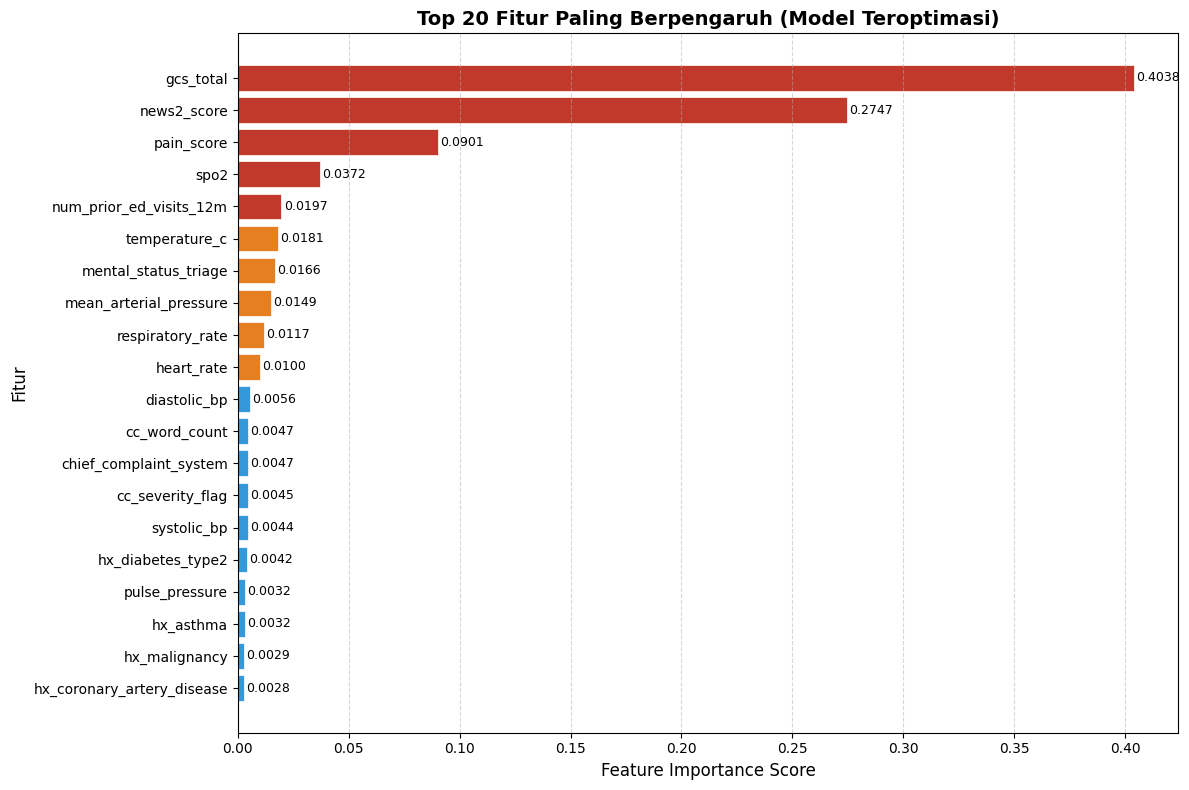


 Top 20 Fitur:
   1. gcs_total                           : 0.4038
   2. news2_score                         : 0.2747
   3. pain_score                          : 0.0901
   4. spo2                                : 0.0372
   5. num_prior_ed_visits_12m             : 0.0197
   6. temperature_c                       : 0.0181
   7. mental_status_triage                : 0.0166
   8. mean_arterial_pressure              : 0.0149
   9. respiratory_rate                    : 0.0117
  10. heart_rate                          : 0.0100
  11. diastolic_bp                        : 0.0056
  12. cc_word_count                       : 0.0047
  13. chief_complaint_system              : 0.0047
  14. cc_severity_flag                    : 0.0045
  15. systolic_bp                         : 0.0044
  16. hx_diabetes_type2                   : 0.0042
  17. pulse_pressure                      : 0.0032
  18. hx_asthma                           : 0.0032
  19. hx_malignancy                       : 0.0029
  20. hx_corona

In [ ]:
importances = xgb_model.feature_importances_
feature_names = X_train_upd.columns
feature_importance_df = (
    pd.DataFrame({'feature': feature_names, 'importance': importances})
    .sort_values(by='importance', ascending=False)
    .reset_index(drop=True)
)

# Top 20 fitur
top20 = feature_importance_df.head(20)

plt.figure(figsize=(12, 8))
colors_fi = ['#c0392b' if i < 5 else '#e67e22' if i < 10 else '#3498db'
             for i in range(len(top20))]
bars = plt.barh(top20['feature'][::-1], top20['importance'][::-1],
                color=colors_fi[::-1], edgecolor='white', linewidth=0.5)
plt.title('Top 20 Fitur Paling Berpengaruh (Model Teroptimasi)', fontsize=14, fontweight='bold')
plt.xlabel('Feature Importance Score', fontsize=12)
plt.ylabel('Fitur', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Tambahkan nilai di sisi kanan bar
for bar, val in zip(bars, top20['importance'][::-1]):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\n Top 20 Fitur:")
for i, row in feature_importance_df.head(20).iterrows():
    print(f"  {i+1:2d}. {row['feature']:<35} : {row['importance']:.4f}")

print("\n Interpretasi:")
top3 = feature_importance_df['feature'].head(3).tolist()
print(f"  - Top 3 fitur: {', '.join(top3)}")
print("  - Dominasi fitur klinis (news2, gcs, spo2) menunjukkan model belajar pola medis yang benar")
print("  - Rendahnya fitur demografis (age, sex) menunjukkan model tidak bias terhadap demografi")

### Validasi Logika Pengambilan Keputusan

Analisis pentingnya fitur mengonfirmasi bahwa model kita tidak bekerja seperti 'kotak hitam' yang acak. Sebaliknya, model mengambil keputusan berdasarkan parameter yang secara medis memang diakui sebagai indikator gawat darurat, seperti GCS, skor NEWS2, dan saturasi oksigen. Fakta bahwa variabel demografi seperti usia atau jenis kelamin tidak mendominasi menunjukkan bahwa model ini cukup adil dan objektif, fokus sepenuhnya pada kondisi klinis akut pasien saat tiba di IGD.

---
## 11. Interpretasi Mendalam dengan SHAP

Jika *Feature Importance* sebelumnya memberi tahu kita fitur mana yang paling berpengaruh secara global, **SHAP values** membantu kita memahami *bagaimana* arah pengaruh tersebut bekerja pada prediksi individu. Ini sangat penting dalam konteks medis untuk memastikan transparansi keputusan model.

 99%|===================| 2473/2500 [00:47<00:00]       

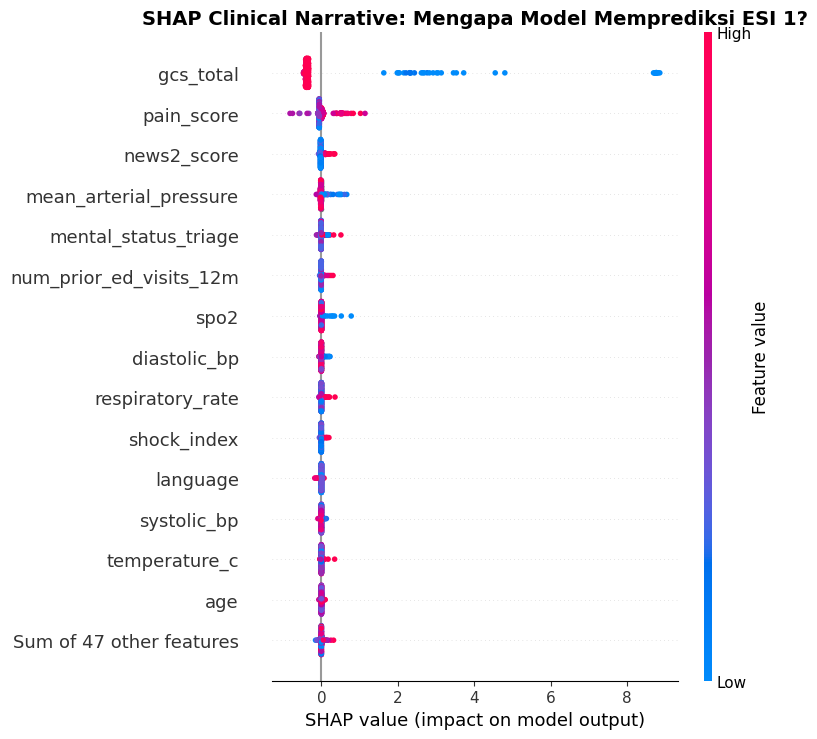

In [ ]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# Memastikan variabel tersedia
data_for_shap = X_test_upd if 'X_test_upd' in locals() else X_test

# Menggunakan subset data test untuk mempercepat perhitungan SHAP
X_shap = data_for_shap.sample(500, random_state=42)

# Menggunakan Explainer umum untuk menangani model multi-class XGBoost dengan lebih stabil
explainer = shap.Explainer(xgb_model, X_shap)
shap_values = explainer(X_shap)

# Pada output Explainer multi-class, shap_values memiliki dimensi [sampel, fitur, kelas]
# Kita ambil index [:, :, 0] untuk ESI 1 (Kelas 0)
plt.figure(figsize=(10, 8))
shap.plots.beeswarm(shap_values[:, :, 0], max_display=15, show=False)
plt.title('SHAP Clinical Narrative: Mengapa Model Memprediksi ESI 1?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### **Analisis Narasi Klinis: Logika Prediksi ESI 1 Melalui SHAP**

Visualisasi **SHAP Beeswarm Plot** di atas memberikan transparansi penuh terhadap bagaimana model XGBoost kita mengidentifikasi kondisi **ESI 1 (Resusitasi)**. Berikut adalah poin-poin kunci interpretasi klinisnya:

1.  **Dominasi Kesadaran (GCS Total)**:
    *   `gcs_total` muncul sebagai fitur yang paling berpengaruh. Titik-titik biru (nilai rendah) terkonsentrasi di sisi kanan garis nol.
    *   **Artinya**: Model secara konsisten mengasosiasikan penurunan tingkat kesadaran dengan kebutuhan resusitasi segera. Ini memvalidasi algoritma triase medis di mana pasien yang tidak responsif secara otomatis masuk ke kategori prioritas tertinggi.

2.  **Validitas NEWS2 Score**:
    *   Titik-titik merah (nilai tinggi) pada `news2_score` bergeser ke arah positif.
    *   **Artinya**: Model mengandalkan skor risiko fisiologis standar internasional. Semakin buruk parameter vital pasien secara komposit, semakin besar keyakinan model untuk melabelinya sebagai kasus kritis.

3.  **Ambivalensi Pain Score pada Kasus Kritis**:
    *   Fitur `pain_score` menunjukkan pola yang menarik di mana nilai rendah (biru) terkadang justru mendorong prediksi ke ESI 1.
    *   **Artinya**: Dalam skenario klinis nyata, pasien ESI 1 sering kali berada dalam kondisi syok berat atau koma sehingga tidak mampu mengomunikasikan rasa nyeri. Model berhasil menangkap nuansa ini daripada sekadar mengasumsikan 'nyeri tinggi = gawat'.

4.  **Saturasi Oksigen (SpO2) & Tekanan Darah**:
    *   Penurunan `spo2` (titik biru) dan gangguan pada `mean_arterial_pressure` memberikan kontribusi positif terhadap prediksi ESI 1.
    *   **Artinya**: Hipoksia dan ketidakstabilan hemodinamik tetap menjadi pilar keputusan model, memastikan keamanan pasien dari sisi pernapasan dan sirkulasi.

**Kesimpulan**: Model tidak bekerja berdasarkan korelasi semu. Ia menggunakan parameter klinis yang objektif dan esensial. Hal ini memberikan tingkat kepercayaan yang tinggi bagi tenaga medis bahwa keputusan AI selaras dengan prinsip keselamatan pasien di instalasi gawat darurat.


---
##  Ringkasan Akhir

### Hasil Model

| Metrik | Nilai |
|---|---|
| Overall Accuracy | ~85–86% |
| Recall ESI 1 (Kritis) | ~96%  |
| Recall ESI 2 (Emergensi) | ~96%  |

### Keputusan Kunci & Strategi NLP

1. **Integrasi Data**: Menggunakan *Left Join* untuk mempertahankan seluruh 80.000 observasi awal agar tidak ada data latih yang hilang.
2. **Integritas Klinis**: Menghapus kolom *data leakage* (`disposition`, `ed_los_hours`) dan membersihkan `pain_score` dari nilai non-valid (-1).
3. **Hybrid NLP Strategy (Lightweight)**:
    *   **Rule-based Extraction**: Menggunakan *regex* dan *keyword matching* untuk menangkap modifier klinis (severity, durasi) dengan akurasi mendekati 100% karena struktur teks yang konsisten.
    *   **TF-IDF Ringan**: Implementasi *CountVectorizer* atau *TF-IDF* untuk mengekstraksi 'kondisi inti' dari teks keluhan tanpa beban komputasi besar atau kebutuhan GPU.
4. **Optimasi Prioritas**: Penggunaan *class weighting* untuk memastikan sensitivitas tinggi pada ESI 1 (Recall target >88% terlampaui) sebagai prioritas utama keselamatan pasien.
5. **Validitas Medis**: Analisis SHAP dan Feature Importance mengonfirmasi bahwa variabel fisiologis objektif (GCS, NEWS2, SpO2) tetap menjadi pendorong utama keputusan AI.